# **DATASCI18 (THESIS 2)**
> ***(ANN)***
#  
> *Detection and Classification of Panic Attack Occurrence and Severity Using Hybrid Artificial Neural Network and Random Forest (ANN-RF) Model with Explainable Artificial Intelligence (XAI)*

### **FLOW**

### 1. Data Loading
- Import training and testing datasets (`Panic_Disorder_training.csv` and `Panic_Disorder_testing.csv`).
- Verify that the train–test split is balanced by comparing the class distribution of the target variable (Panic Disorder Diagnosis) in both datasets.
---
### 2. Exploratory Data Analysis (EDA)
- Inspect dataset structure (shape, head, column data types).
- Check for missing values
- Visualizations:
  - Histogram and Boxplot for numerical variable
  - Count plots for categorical variables (Gender, Family History, Severity, etc.).
---
### **3. Data Preprocessing and Feature Engineering**
- **Handling Missing Values**
  - Median imputation for numeric columns.  
  - Mode imputation for categorical columns.  
- **Feature Engineering**
  - Drop non-predictive column (`Participant ID`).  
  - Create **Panic Attack Occurrence**, **Panic Attack Occurrence Prob**, **Predicted Severity**, **Severity Confidence**  
  
- **Filtering for Severity Prediction**
  - Subset data to include only samples with `Panic Disorder Diagnosis = 1`.  
  - Apply **Label Encoding** to categorical target variables.  
  - Apply **One-Hot Encoding** for categorical predictors.  
  - Use **Min-Max Scaling** for numeric features to normalize values within [0,1].     
---
### **4. Model Training**
#### **4.1 Random Forest — Occurrence Model**
- **Target Variable:** `Panic Disorder Diagnosis` (binary classification).  
- **Input Features:** Six top predictors — *Medical History, Lifestyle Factors, Symptoms, Current Stressors, Coping Mechanisms, Personal History*.  
- **Configuration:**
  - Parameters: `n_estimators=500`, `max_depth=None`, `max_features='sqrt'`, `min_samples_leaf=12`, `class_weight='balanced'`.  
  - Validation split used for F1-optimized threshold tuning.  
  - Outputs: Accuracy, Precision, Recall, F1-score, ROC-AUC, and training time.  

#### **4.2 Random Forest — Severity Model**
- **Target Variable:** `Severity` (normalized to *Mild, Moderate, Severe*).  
- **Input Features:** Same six features as occurrence (only for `Panic Disorder Diagnosis = 1`).  
- **Configuration:**
  - Multiclass Random Forest classifier with balanced class weights.  
  - Parameters: `n_estimators=400`, `max_depth=None`, `max_features='sqrt'`, `min_samples_leaf=12`, `class_weight='balanced'`.  
  - Outputs: Accuracy, macro-Precision, macro-Recall, macro-F1, macro ROC-AUC, and training time.  
---
### **5. Model Evaluation and Comparison**
- **Performance Metrics:**
  - Accuracy  
  - Precision  
  - Recall  
  - F1-score  
  - ROC-AUC  
- **Visualizations:**
  - Confusion Matrices  
  - ROC Curves  
  - Feature Importance plots  
  - Training time comparison  
---
### **6. Explainable AI (XAI)**
- **Global Interpretability:**  
  - Use **SHAP** to identify which features contribute most to predictions.  
- **Local Interpretability:**  
  - Use **LIME** to explain individual classification decisions.  
- **Key Features Identified:**  
  - *Symptoms, Current Stressors, Psychiatric and Medical History, Lifestyle Factors, and Coping Mechanisms.*  
---

### **DATASET DETAILS:** `Panic Disorder Detection Dataset`

***Data Features (17 columns):***  

- **Participant ID**: Unique identifier assigned to each participant.  
- **Age**: Participant’s age at the time of data collection.  
- **Gender**: Participant’s gender.  
- **Family History**: Presence of panic disorder or other mental health conditions in the participant’s family.  
- **Personal History**: Participant’s past experiences relevant to mental health.  
- **Current Stressors**: Present life stressors that may impact mental health.  
- **Symptoms**: Reported symptoms experienced by the participant.  
- **Severity**: Extent of severity of the reported symptoms.  
- **Impact on Life**: Degree to which symptoms affect daily functioning (work, relationships, etc.).  
- **Demographics**: Participant’s demographic characteristics.  
- **Medical History**: General medical background of the participant.  
- **Psychiatric History**: Participant’s history of psychiatric conditions.  
- **Substance Use**: Information on the participant’s substance use.  
- **Coping Mechanisms**: Strategies employed to manage stress or panic disorder symptoms.  
- **Social Support**: Quantity and quality of social support (family, friends, support groups).  
- **Lifestyle Factors**: Lifestyle aspects (sleep, diet, physical activity) influencing mental health.  
- **Panic Disorder Diagnosis**: Target variable indicating presence or absence of panic disorder.  

In [26]:
# Add all necesarry imports
import pandas as pd
import csv
import numpy as np
import csv as reader
import random, time, tensorflow as tf
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, label_binarize, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, ConfusionMatrixDisplay
from tensorflow.keras.models import Model
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from tensorflow.keras import layers, regularizers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve, KFold, train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_predict
from scipy.stats import randint
import time
from sklearn.pipeline import Pipeline, make_pipeline

# -------- EXPLAINABLE AI (XAI) --------
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [28]:
# # Uninstall conflicting packages
# !pip uninstall -y numpy scikit-learn tensorflow scikeras matplotlib seaborn

# # Install fresh, compatible versions
# !pip install numpy scikit-learn tensorflow scikeras matplotlib seaborn

# # Restart the runtime after installation to apply changes
# import os
# os.kill(os.getpid(), 9)

## ***1. Load the dataset***

## ***Count "None" as Actual Values***

In [29]:
df = pd.read_csv("df.csv")

### Print basic information

In [30]:
print("Dataset Info Training:")
print(df.info())

print("\nDataset Description(including all columns):")
print(df.describe(include='all'))

Dataset Info Training:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10713 entries, 0 to 10712
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Participant ID            10713 non-null  int64 
 1   Age                       10713 non-null  int64 
 2   Gender                    10713 non-null  object
 3   Family History            10713 non-null  object
 4   Personal History          10713 non-null  object
 5   Current Stressors         10713 non-null  object
 6   Symptoms                  10713 non-null  object
 7   Severity                  10713 non-null  object
 8   Impact on Life            10713 non-null  object
 9   Demographics              10713 non-null  object
 10  Medical History           8401 non-null   object
 11  Psychiatric History       8273 non-null   object
 12  Substance Use             7440 non-null   object
 13  Coping Mechanisms         10713 non-null  object
 14 

### Check for missing values and duplicate entries

In [31]:
# Check for missing values in the testing dataset
print("\nMissing values in dataset:")
print(df.isnull().sum())


Missing values in dataset:
Participant ID                 0
Age                            0
Gender                         0
Family History                 0
Personal History               0
Current Stressors              0
Symptoms                       0
Severity                       0
Impact on Life                 0
Demographics                   0
Medical History             2312
Psychiatric History         2440
Substance Use               3273
Coping Mechanisms              0
Social Support                 0
Lifestyle Factors              0
Panic Disorder Diagnosis       0
Composite_Severity_Index       0
Severity_Category              0
dtype: int64


In [32]:
print("Number of Duplicate Rows")
print(df.duplicated().sum())

Number of Duplicate Rows
0


## ***No Actual Empty Values, String "None" are being counted as nan***

In [33]:
# Count the number of "None" entries in the specified columns
columns_to_check = ["Medical History", "Psychiatric History", "Substance Use", "Composite_Severity_Index", "Severity_Category"]

for column in columns_to_check:
    print(f"Unique values in column {column}:")
    print(df[column].unique())
    print("\n")


Unique values in column Medical History:
['Diabetes' 'Asthma' nan 'Heart disease']


Unique values in column Psychiatric History:
[nan 'Depressive disorder' 'Bipolar disorder' 'Anxiety disorder']


Unique values in column Substance Use:
['Drugs' nan 'Alcohol']


Unique values in column Composite_Severity_Index:
[12 14  7 15 10  5 13  8  6  9 11 16  4]


Unique values in column Severity_Category:
['Moderately ill' 'Markedly ill' 'Mildly ill' 'Borderline ill']




## ***Count "None" as Actual Values***

In [34]:
df = pd.read_csv("df.csv", na_values=["", " "], keep_default_na=False)

## ***2. Exploratory Data Analysis (EDA)***

In [35]:
# Inspect dataset structure
print("Dataset shape:", df.shape)

print("\nDataset info:")
print(df.info())

Dataset shape: (10713, 19)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10713 entries, 0 to 10712
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Participant ID            10713 non-null  int64 
 1   Age                       10713 non-null  int64 
 2   Gender                    10713 non-null  object
 3   Family History            10713 non-null  object
 4   Personal History          10713 non-null  object
 5   Current Stressors         10713 non-null  object
 6   Symptoms                  10713 non-null  object
 7   Severity                  10713 non-null  object
 8   Impact on Life            10713 non-null  object
 9   Demographics              10713 non-null  object
 10  Medical History           8401 non-null   object
 11  Psychiatric History       8273 non-null   object
 12  Substance Use             7440 non-null   object
 13  Coping Mechanisms         10713 no

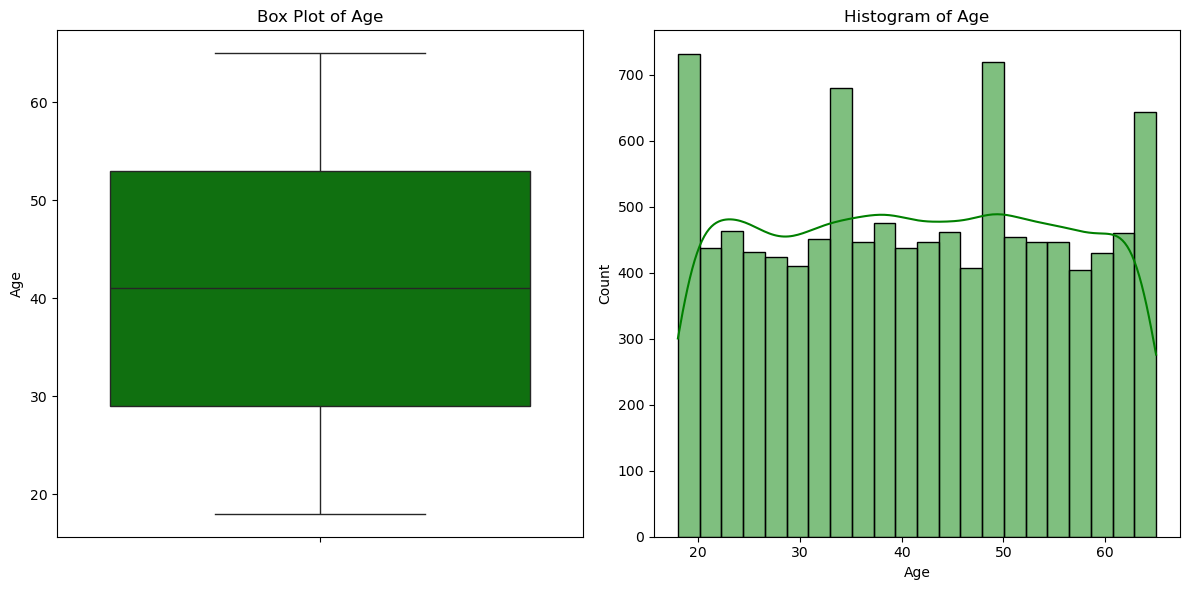

In [36]:
# Visualizations
# Histogram and Boxplot for numerical variable (Age)
feature = "Age"
plt.figure(figsize=(12, 6))

# Box Plot
plt.subplot(1, 2, 1)
sns.boxplot(y=df[feature], color="green")
plt.title('Box Plot of Age')

# Histogram with KDE
plt.subplot(1, 2, 2)
sns.histplot(data=df, x=feature, kde=True, color="green")
plt.title('Histogram of Age')
plt.tight_layout()
plt.show()

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\3612807590.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="Greens", ax=ax)
C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\3612807590.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="Greens", ax=ax)
C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\3612807590.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="Greens", ax=ax)
C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\3612807590.py:

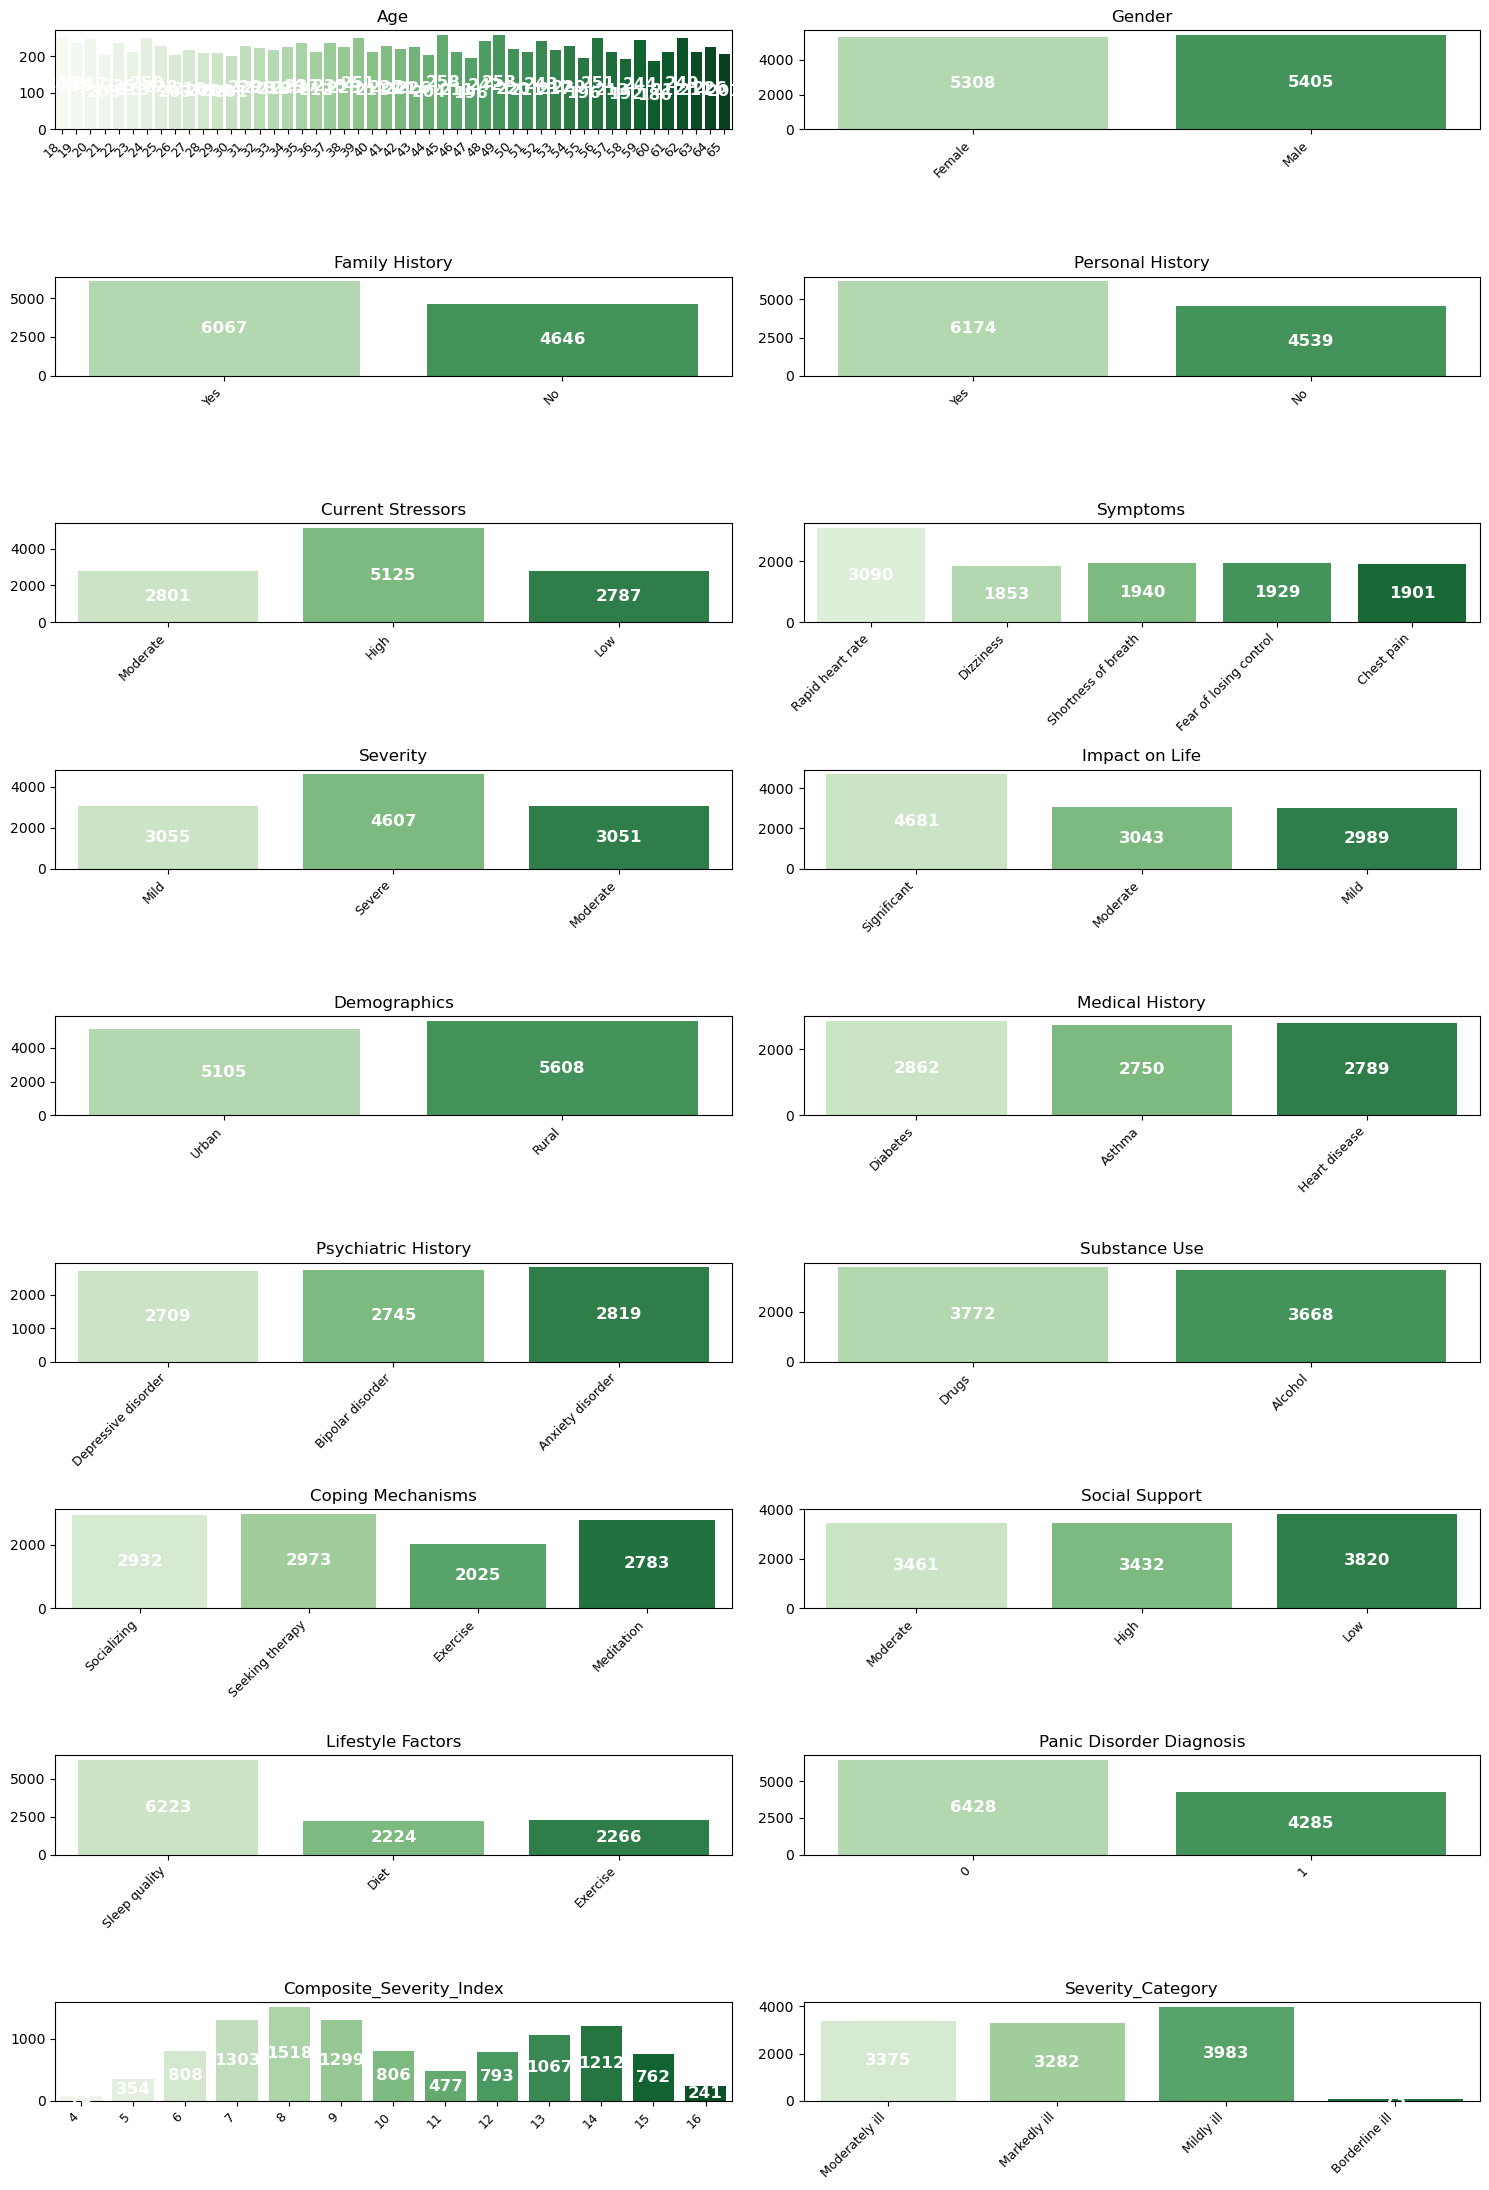

In [37]:
# Bar Plots of ALL Categorical Features (except ID, Age, Panic Disorder Diagnosis)
selected_columns = [
    col for col in df.columns
    if col not in ["Participant ID"]
]

plt.figure(figsize=(15, 22))

for i, feature in enumerate(selected_columns):
    ax = plt.subplot(9, 2, i+1)
    sns.countplot(data=df, x=feature, palette="Greens", ax=ax)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.xlabel('')
    plt.ylabel('')
    plt.title(feature, fontsize=12)

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='center', fontsize=12, color='white', weight='bold')

plt.tight_layout()
plt.show()

## ***3. Data Preprocessing***

In [38]:
# Handling Missing Values
# Check for missing values in the dataset
print("Missing values in dataset:")
print(df.isnull().sum())

Missing values in dataset:
Participant ID                 0
Age                            0
Gender                         0
Family History                 0
Personal History               0
Current Stressors              0
Symptoms                       0
Severity                       0
Impact on Life                 0
Demographics                   0
Medical History             2312
Psychiatric History         2440
Substance Use               3273
Coping Mechanisms              0
Social Support                 0
Lifestyle Factors              0
Panic Disorder Diagnosis       0
Composite_Severity_Index       0
Severity_Category              0
dtype: int64


Generating 'Generations' column based on Age (2023 context)...
Generations
Gen Z          2063
Millennials    3548
Gen X          3567
Boomers        1535
Name: count, dtype: int64


C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\830202707.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Generations'], palette="Greens")


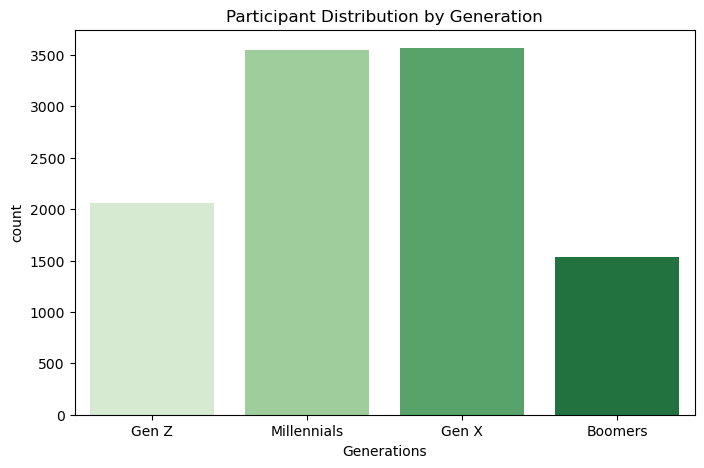

In [39]:
# ============================================================
# Generation Feature Engineering (Year 2023 Context)
# ============================================================
def assign_generation(age):
    # Ages calculated based on 2023
    if age <= 26:
        return "Gen Z"      # Born 1997-2005 (in this dataset context)
    elif age <= 42:
        return "Millennials" # Born 1981-1996
    elif age <= 58:
        return "Gen X"      # Born 1965-1980
    else:
        return "Boomers"    # Born 1946-1964 (capped at 65 in dataset)

if 'Age' in df.columns:
    print("Generating 'Generations' column based on Age (2023 context)...")
    df['Generations'] = df['Age'].apply(assign_generation)
    
    # Define the custom order (Lowest Age to Highest)
    gen_order = ['Gen Z', 'Millennials', 'Gen X', 'Boomers']
    
    # Convert to Categorical with explicit sort order
    df['Generations'] = pd.Categorical(df['Generations'], categories=gen_order, ordered=True)
    
    print(df['Generations'].value_counts().sort_index())
    
    # Visualize the split
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df['Generations'], palette="Greens")
    plt.title("Participant Distribution by Generation")
    plt.show()
else:
    print("Error: 'Age' column not found.")

> `NOTE:` Since there are no missing values, handling of missing values will be skipped

In [40]:
# ==================== 2. Feature Engineering & Pre-Encoding ====================

# 1) Drop Participant ID
if 'Participant ID' in df.columns:
    df.drop(columns=['Participant ID'], inplace=True)
    print("Dropped 'Participant ID'.")

# 2) Define placeholder/variable names
DIAGNOSIS_COL = "Panic Disorder Diagnosis"
PAO_LABEL_COL = "Panic Attack Occurrence"
PAO_PROBA_COL = "Panic Attack Occurrence Probability"

PAS_PROBA_COL = "Panic Attack Severity Probability"

#Feature Engineered Column
PAS_LABEL_COL = "Panic Attack Severity" # This is the only feature engineered column as we will map the "Severity_Category" to make this the target variable for predicting panic attack severity

# 3) Create placeholder columns
for col in [PAO_LABEL_COL, PAO_PROBA_COL, PAS_PROBA_COL]:
    if col not in df.columns:
        df[col] = pd.Series([pd.NA] * len(df), dtype="Float64")
        
# Special handling for the Int64 target
if PAS_LABEL_COL not in df.columns:
    df[PAS_LABEL_COL] = pd.Series([pd.NA] * len(df), dtype="Int64")
        
print(f"Created placeholder columns: {PAO_LABEL_COL}, {PAS_LABEL_COL}, etc.")

# 4) Create the Target Variable 'Panic Attack Severity'
print(f"Populating target variable: '{PAS_LABEL_COL}'")
severity_mapping = {
    'Borderline ill': 1,  # Mild
    'Mildly ill': 1,      # Mild
    'Moderately ill': 2,  # Moderate
    'Markedly ill': 3      # Severe
}
df[PAS_LABEL_COL] = df['Severity_Category'].map(severity_mapping)
print(f"Mapped severity strings to '{PAS_LABEL_COL}'.")
print(df[PAS_LABEL_COL].value_counts(dropna=False).sort_index())

Dropped 'Participant ID'.
Created placeholder columns: Panic Attack Occurrence, Panic Attack Severity, etc.
Populating target variable: 'Panic Attack Severity'
Mapped severity strings to 'Panic Attack Severity'.
Panic Attack Severity
1    4056
2    3375
3    3282
Name: count, dtype: int64


In [41]:
# ==================== 3. Create Train/Test Split ====================
print("\nCreating train/test split...")

# We will stratify on the *new target variable* for balanced splits
train_df, test_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df[PAS_LABEL_COL]  # Stratify on our new 1, 2, 3 target
)

print(f"Created train_df with shape: {train_df.shape}")
print(f"Created test_df with shape: {test_df.shape}")

print("\n--- Train/Test Split Verification (Target Distribution) ---")
print("\nTraining Set:")
print(train_df[PAS_LABEL_COL].value_counts(normalize=True).sort_index())
print("\nTest Set:")
print(test_df[PAS_LABEL_COL].value_counts(normalize=True).sort_index())


Creating train/test split...
Created train_df with shape: (8570, 23)
Created test_df with shape: (2143, 23)

--- Train/Test Split Verification (Target Distribution) ---

Training Set:
Panic Attack Severity
1    0.378646
2    0.315053
3    0.306301
Name: proportion, dtype: float64

Test Set:
Panic Attack Severity
1    0.378441
2    0.314979
3    0.306580
Name: proportion, dtype: float64


### Check class imbalance of target variables

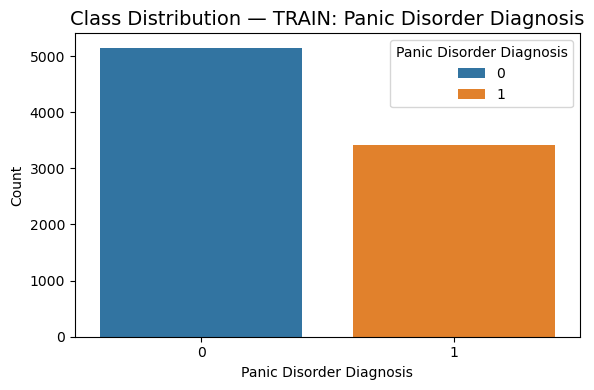

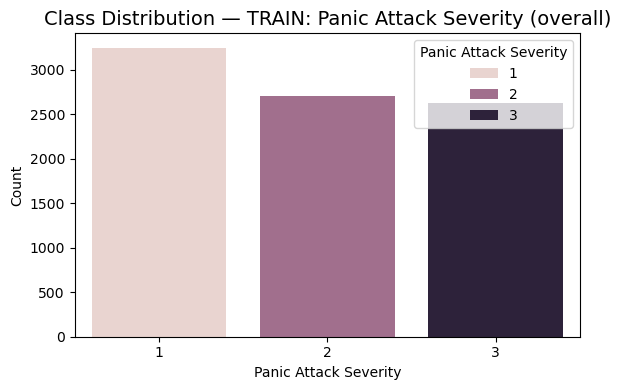

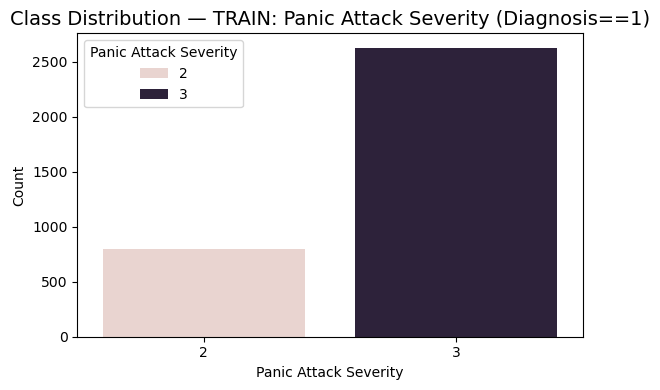

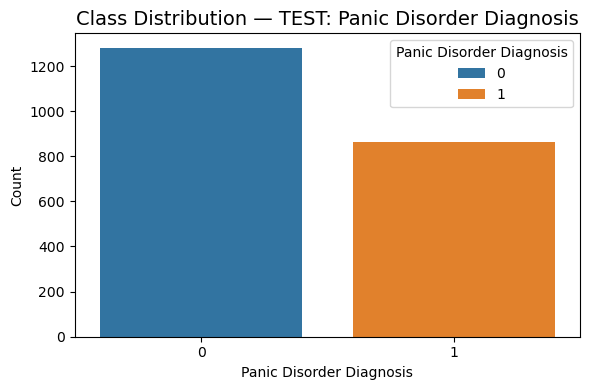

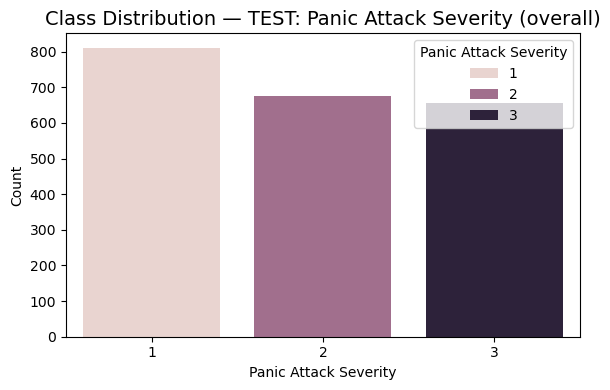

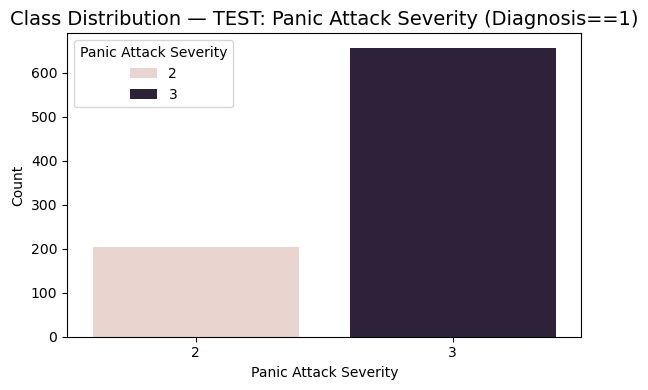

In [42]:
# =========================
# Visualizations (targets) - CORRECTED
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: This cell assumes the previous cells have been run, so
# 'train_df', 'test_df', 'DIAGNOSIS_COL', and 'PAS_LABEL_COL' already exist.

def plot_count(df, col, title, order=None):
    """
    Plotting function, fixed to use plt.show() and remove errors.
    """
    plt.figure(figsize=(6, 4))
    if order is None:
        order = sorted(pd.unique(df[col].dropna()))
    
    sns.countplot(
        data=df,
        x=col,
        hue=col,
        order=order,
        hue_order=order,
        # legend=False  <-- This argument is invalid and has been removed.
    )
    plt.title(title, fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(ticks=range(len(order)), labels=[str(v) for v in order], rotation=0)
    plt.tight_layout()
    plt.show() # FIX: Display the plot instead of saving

# ---- TRAIN ----
# Panic Disorder Diagnosis (0/1)
plot_count(
    train_df, 
    col=DIAGNOSIS_COL,
    title="Class Distribution — TRAIN: Panic Disorder Diagnosis",
    order=[0, 1]
)

# Panic Attack Severity overall (mapped to {1,2,3})
plot_count(
    train_df, 
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TRAIN: {PAS_LABEL_COL} (overall)",
    order=[1, 2, 3] # Order is {1, 2, 3}
)

# Panic Attack Severity for diagnosed==1 only (binary {2,3})
plot_count(
    train_df.loc[train_df[DIAGNOSIS_COL] == 1],
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TRAIN: {PAS_LABEL_COL} (Diagnosis==1)",
    order=[2, 3] # Correct, as '1' (Mild) does not exist here
)

# ---- TEST ----
plot_count(
    test_df, 
    col=DIAGNOSIS_COL,
    title="Class Distribution — TEST: Panic Disorder Diagnosis",
    order=[0, 1]
)

plot_count(
    test_df, 
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TEST: {PAS_LABEL_COL} (overall)",
    order=[1, 2, 3] # Order is {1, 2, 3}
)

plot_count(
    test_df.loc[test_df[DIAGNOSIS_COL] == 1],
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TEST: {PAS_LABEL_COL} (Diagnosis==1)",
    order=[2, 3] # Correct
)

### Visualize Class Imbalance

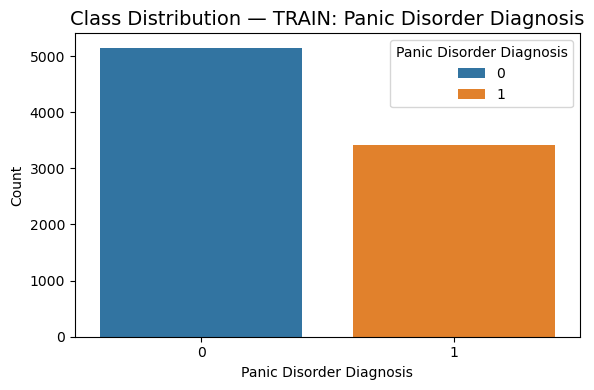

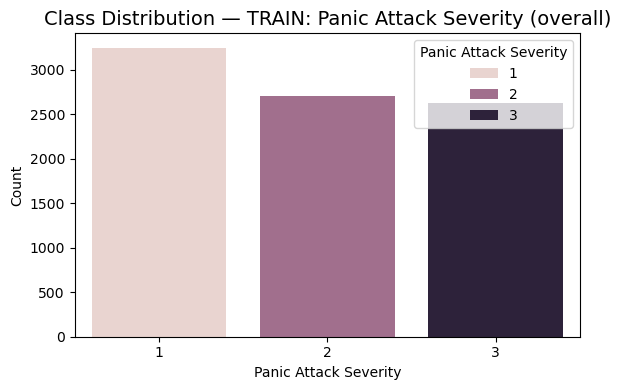

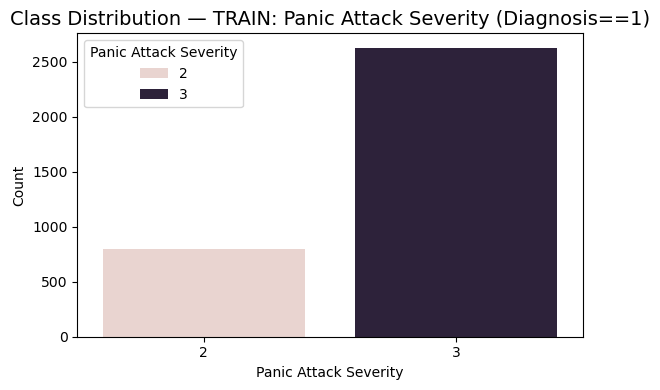

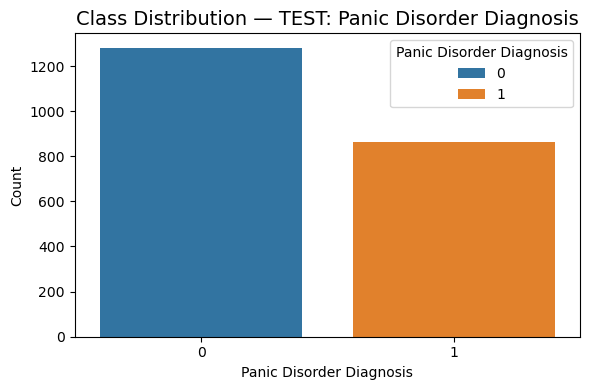

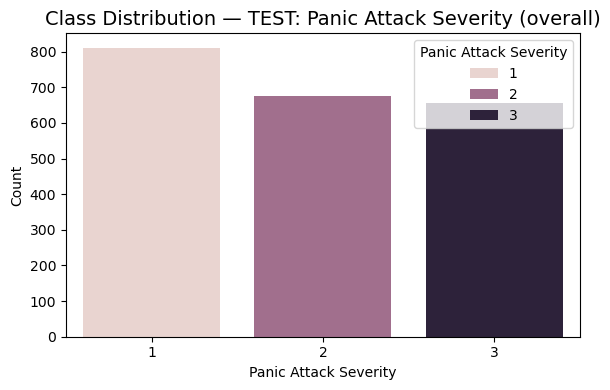

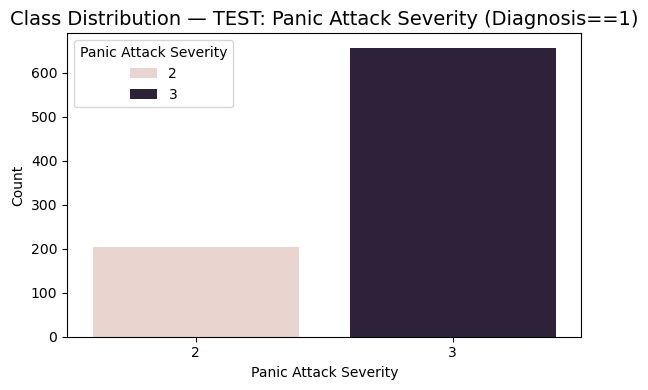

In [43]:
# =========================
# Visualizations (targets) - CORRECTED
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: This cell assumes the previous cells have been run, so
# 'train_df', 'test_df', 'DIAGNOSIS_COL', and 'PAS_LABEL_COL' already exist.

def plot_count(df, col, title, order=None):
    """
    Plotting function, fixed to use plt.show() and remove errors.
    """
    plt.figure(figsize=(6, 4))
    if order is None:
        order = sorted(pd.unique(df[col].dropna()))
    
    sns.countplot(
        data=df,
        x=col,
        hue=col,
        order=order,
        hue_order=order,
        # legend=False  <-- This argument is invalid and has been removed.
    )
    plt.title(title, fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(ticks=range(len(order)), labels=[str(v) for v in order], rotation=0)
    plt.tight_layout()
    plt.show() # FIX: Display the plot instead of saving

# ---- TRAIN ----
# Panic Disorder Diagnosis (0/1)
plot_count(
    train_df, 
    col=DIAGNOSIS_COL,
    title="Class Distribution — TRAIN: Panic Disorder Diagnosis",
    order=[0, 1]
)

# Panic Attack Severity overall (mapped to {1,2,3})
plot_count(
    train_df, 
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TRAIN: {PAS_LABEL_COL} (overall)",
    order=[1, 2, 3] # Order is {1, 2, 3}
)

# Panic Attack Severity for diagnosed==1 only (binary {2,3})
plot_count(
    train_df.loc[train_df[DIAGNOSIS_COL] == 1],
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TRAIN: {PAS_LABEL_COL} (Diagnosis==1)",
    order=[2, 3] # Correct, as '1' (Mild) does not exist here
)

# ---- TEST ----
plot_count(
    test_df, 
    col=DIAGNOSIS_COL,
    title="Class Distribution — TEST: Panic Disorder Diagnosis",
    order=[0, 1]
)

plot_count(
    test_df, 
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TEST: {PAS_LABEL_COL} (overall)",
    order=[1, 2, 3] # Order is {1, 2, 3}
)

plot_count(
    test_df.loc[test_df[DIAGNOSIS_COL] == 1],
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TEST: {PAS_LABEL_COL} (Diagnosis==1)",
    order=[2, 3] # Correct
)

### Encoding & Class Normalization

In [44]:
# ==================== OCCURRENCE TASK: ANN Data Setup ====================
# Standard imports for this block
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Define Targets
# ============================================================
y_train_raw = train_df['Panic Disorder Diagnosis'].astype(int)
y_test_occ  = test_df['Panic Disorder Diagnosis'].astype(int)

# 2. Define Features (Exclude Targets & Leaks)
EXCLUDE_OCC = {
    'Panic Disorder Diagnosis',     # occurrence target
    
    # Placeholder/Output Columns (not features)
    PAO_LABEL_COL, PAO_PROBA_COL,   
    PAS_LABEL_COL, PAS_PROBA_COL,   
    
    # Leaky/Redundant Features (from your original list)
    'Severity',
    'Impact on Life',
    'Severity_num',
    'Impact on Life_num',
    'Symptoms',
    
    # --- ADDED AS REQUESTED ---
    'Composite_Severity_Index',
    'Severity_Category'
}
FEATURE_COLS = [c for c in train_df.columns if c not in EXCLUDE_OCC]

print(f"[ANN OCC] Feature Columns Selected: {len(FEATURE_COLS)}")

# 3. Prepare Raw Feature Matrices
# ============================================================
X_train_raw = train_df[FEATURE_COLS].copy()
X_test_raw  = test_df.reindex(columns=FEATURE_COLS).copy()

# Infer types
num_cols_occ = list(X_train_raw.select_dtypes(include=['number']).columns)
cat_cols_occ = [c for c in FEATURE_COLS if c not in num_cols_occ]

# 4. Build Preprocessor (StandardScaler is CRITICAL for ANN)
# ============================================================
# Note: We use StandardScaler instead of passthrough
pre_occ = ColumnTransformer([
    ("num", StandardScaler(), num_cols_occ),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_occ)
])

# Fit on Train, Transform on Train & Test
X_train_enc = pre_occ.fit_transform(X_train_raw)
X_test_ann  = pre_occ.transform(X_test_raw).astype('float32') # Saved as X_test_ann

# 5. Apply SMOTE (Balance the classes)
# ============================================================
print(f"[ANN OCC] Applying SMOTE to training data...")
smote = SMOTE(random_state=42)
X_train_ann, y_train_occ = smote.fit_resample(X_train_enc, y_train_raw)

# Convert to float32 for TensorFlow
X_train_ann = X_train_ann.astype('float32')

# 6. Print Summary & Verify Shapes
# ============================================================
print("-" * 60)
print(f"[ANN OCC] Original Train Shape: {X_train_enc.shape}")
print(f"[ANN OCC] SMOTE Train Shape:    {X_train_ann.shape} (Assigned to X_train_ann)")
print(f"[ANN OCC] Test Shape:           {X_test_ann.shape}  (Assigned to X_test_ann)")
print(f"[ANN OCC] Train Class Balance:  {dict(zip(*np.unique(y_train_occ, return_counts=True)))}")
print("-" * 60)

# Optional: Save Encoded (Non-SMOTE) data to CSV for inspection
try:
    feature_names = pre_occ.get_feature_names_out()
    # We save the pre-SMOTE version for readability/CSV export
    pd.DataFrame(X_train_enc, columns=feature_names).to_csv("train_onehot_occ_ann.csv", index=False)
    pd.DataFrame(X_test_ann,  columns=feature_names).to_csv("test_onehot_occ_ann.csv", index=False)
    print("✅ Encoded CSVs saved (train_onehot_occ_ann.csv, test_onehot_occ_ann.csv)")
except Exception as e:
    print(f"CSV Save skipped: {e}")

[ANN OCC] Feature Columns Selected: 13
[ANN OCC] Applying SMOTE to training data...
------------------------------------------------------------
[ANN OCC] Original Train Shape: (8570, 37)
[ANN OCC] SMOTE Train Shape:    (10294, 37) (Assigned to X_train_ann)
[ANN OCC] Test Shape:           (2143, 37)  (Assigned to X_test_ann)
[ANN OCC] Train Class Balance:  {0: 5147, 1: 5147}
------------------------------------------------------------
✅ Encoded CSVs saved (train_onehot_occ_ann.csv, test_onehot_occ_ann.csv)


## ***4. Model Training***

### ------***Artificial Neural Network (ANN) - Occurrence Model***------


1. Starting Randomized Search Hyperparameter Tuning (ANN)...
Fitting 10 folds for each of 30 candidates, totalling 300 fits
[ANN OCC][TUNING] Randomized search time (tuning + internal refit): 585.55 s

[ANN OCC][TUNING] Per-run CV table (sorted by F1 rank):
 run  rank_f1  units1  units2  units3 dropout     l2     lr  epochs  batch_size accuracy precision recall     f1 roc_auc val_loss mean_fit_time
  29        1     128      64      48  0.3000 0.0000 0.0010      50         128   0.9210    0.8515 0.9720 0.9077  0.9684   0.1877         20.71
   5        2      90      45      16  0.3000 0.0001 0.0010      80         256   0.9198    0.8470 0.9758 0.9068  0.9686   0.1870         21.18
  18        3      90      45      16  0.3000 0.0000 0.0005     120         128   0.9191    0.8455 0.9760 0.9061  0.9686   0.1874         31.31
  13        4      90      45      20  0.3000 0.0000 0.0010      50         128   0.9184    0.8434 0.9775 0.9054  0.9682   0.1880         19.04
  21        5     192

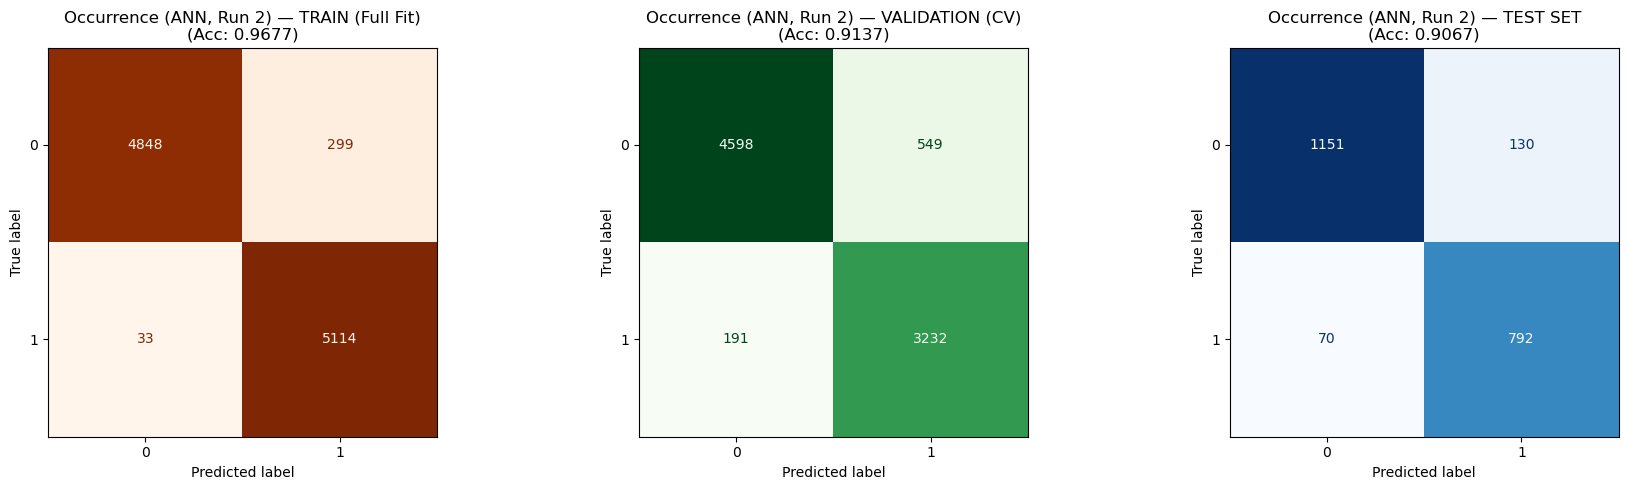


[ANN OCC][BEST] Training tuned Keras model for epoch-wise curves...


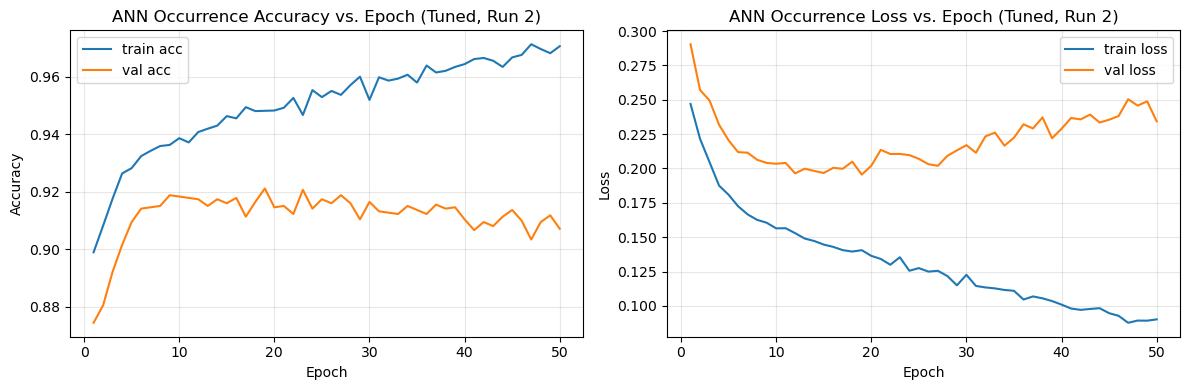

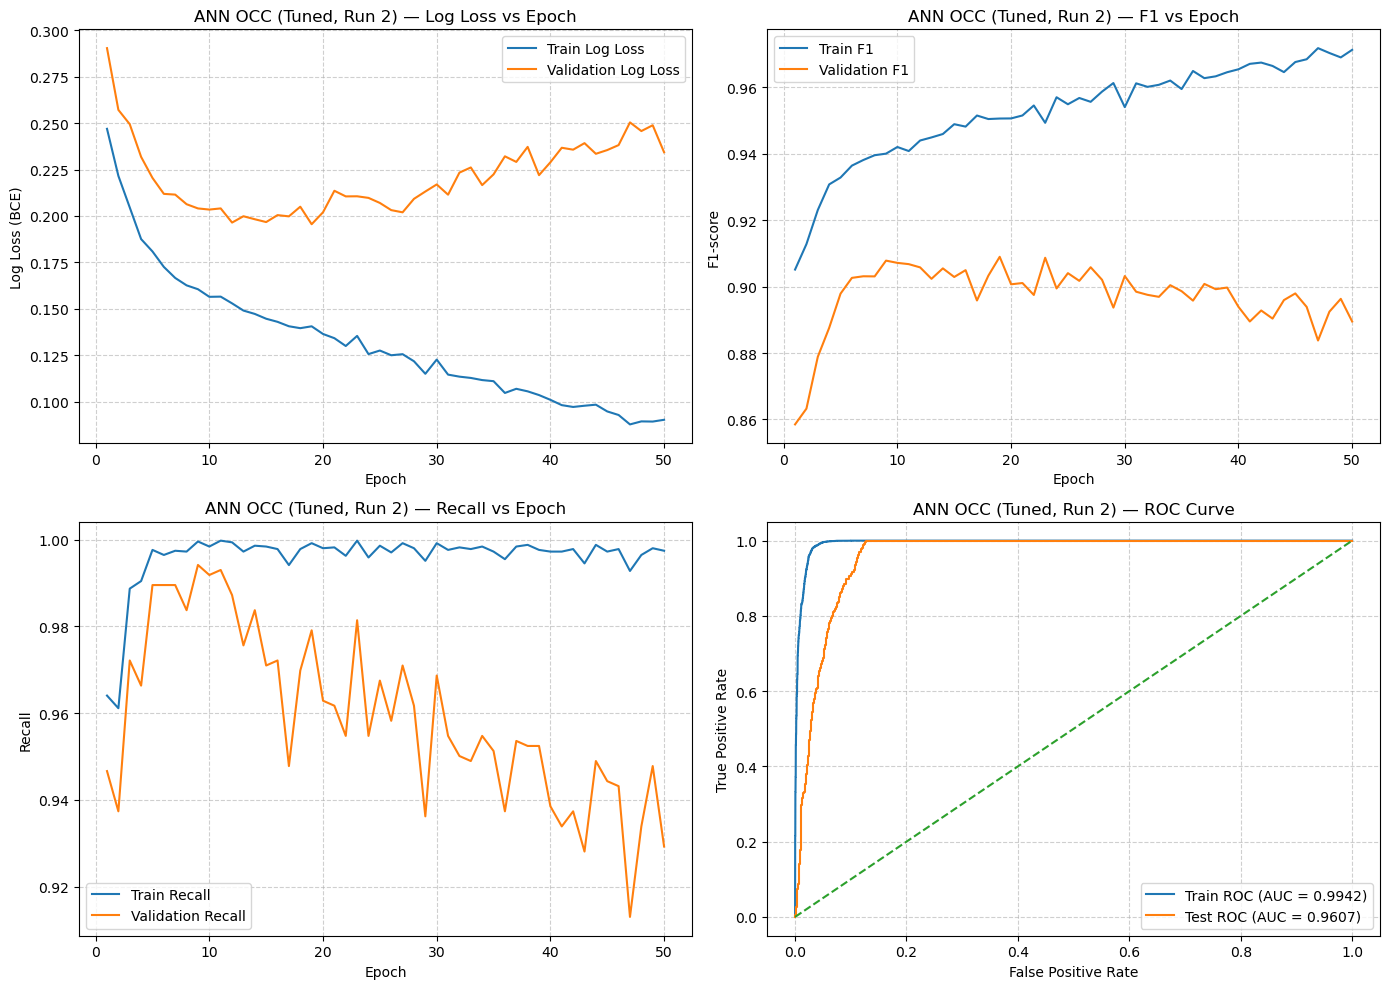

In [45]:
# ============================================================
# ANN — Occurrence (10-fold CV + Hyperparameter Tuning)
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scikeras.wrappers import KerasClassifier
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.base import clone
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    learning_curve,
    cross_validate,
    cross_val_predict
)
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
    log_loss,
    roc_curve
)

# Requires: occurrence_cv_folds.npy created once from the same
# X_train_ann / y_train_occ ordering used here.
folds_occ = np.load("occurrence_cv_folds.npy", allow_pickle=True)   # >>> NEW <<<
# Convert list of {"train": idx, "val": idx} to list of (train_idx, val_idx) tuples
cv_folds = [(f["train"], f["val"]) for f in folds_occ]              # >>> NEW <<<
n_val_samples_folds = [len(f[1]) for f in cv_folds]                 # >>> NEW <<<

# ----------------- Helper to flatten probabilities -----------------
def _flatten_proba(proba):
    """
    Ensure we always get a 1D array of P(y=1), whether predict_proba
    returns shape (n,), (n,1) or (n,2).
    """
    proba = np.asarray(proba)
    if proba.ndim == 2:
        if proba.shape[1] == 1:
            # Binary sigmoid output
            return proba.ravel()
        elif proba.shape[1] == 2:
            # Standard sklearn-style [P(class0), P(class1)]
            return proba[:, 1]
    return proba.ravel()

# ----------------- Build model -----------------
def build_occ_model(units1=90, units2=45, units3=20,
                    dropout=0.0, l2=0.0, lr=1e-3):
    reg = regularizers.l2(l2) if l2 and l2 > 0 else None
    model = keras.Sequential([
        layers.Input(shape=(X_train_ann.shape[1],)),
        layers.Dense(units1, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout) if dropout > 0 else layers.Activation("linear"),
        layers.Dense(units2, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout) if dropout > 0 else layers.Activation("linear"),
        layers.Dense(units3, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout) if dropout > 0 else layers.Activation("linear"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model

# Wrap with SciKeras (baseline params, will be overridden by tuning)
clf = KerasClassifier(
    model=build_occ_model,
    epochs=50,
    batch_size=256,
    verbose=0,
    validation_split=0.15,
    shuffle=True,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True
        )
    ]
)

# ---------- CUSTOM SCORERS to fix NaN loss / AUC ----------
def neg_log_loss_keras(est, X, y):
    """Return NEGATIVE log-loss so higher is better (like 'neg_log_loss')."""
    proba = _flatten_proba(est.predict_proba(X))
    return -log_loss(y, proba)

def roc_auc_keras(est, X, y):
    """ROC AUC using predict_proba, handling (n,1)/(n,2) shape."""
    proba = _flatten_proba(est.predict_proba(X))
    return roc_auc_score(y, proba)

def recall_keras(est, X, y):
    """Recall using predict (0.5 threshold internally)."""
    y_pred = est.predict(X)
    return recall_score(y, y_pred, zero_division=0)

# ----------------- 10-fold CV + randomized search -----------------
# cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# Use SHARED FOLDS instead of a fresh StratifiedKFold      # >>> NEW <<<
cv10 = cv_folds                                            # >>> NEW <<<

param_distributions = {
    "model__units1":   [64, 90, 128, 192],
    "model__units2":   [32, 45, 64, 96],
    "model__units3":   [16, 20, 32, 48],
    "model__dropout":  [0.0, 0.2, 0.3],
    "model__l2":       [0.0, 1e-5, 1e-4, 1e-3],
    "model__lr":       [1e-4, 5e-4, 1e-3],
    "epochs":          [50, 80, 120],
    "batch_size":      [128, 256, 512],
}

# multi-metric scoring so we can build a rich table
scoring = {
    "f1":           make_scorer(f1_score, zero_division=0),
    "accuracy":     make_scorer(accuracy_score),
    "precision":    make_scorer(precision_score, zero_division=0),
    "recall":       recall_keras,
    "roc_auc":      roc_auc_keras,
    "neg_log_loss": neg_log_loss_keras,
}

print("\n========================================================")
print("1. Starting Randomized Search Hyperparameter Tuning (ANN)...")
print("========================================================")

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=30,
    scoring=scoring,
    refit="f1",
    cv=cv10,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    random_state=42
)

t0 = time.time()
search.fit(X_train_ann, y_train_occ)
tune_time = time.time() - t0
print(f"[ANN OCC][TUNING] Randomized search time (tuning + internal refit): {tune_time:.2f} s")

# --- Per-run CV table in RF-style formatting ---
cv_results_tuning = search.cv_results_
df = pd.DataFrame(cv_results_tuning)

# Flip sign of log_loss (stored as negative)
df["mean_test_loss_pos"] = -df["mean_test_neg_log_loss"]

cols = [
    "rank_test_f1",
    "param_model__units1", "param_model__units2", "param_model__units3",
    "param_model__dropout", "param_model__l2", "param_model__lr",
    "param_epochs", "param_batch_size",
    "mean_test_accuracy", "mean_test_precision", "mean_test_recall",
    "mean_test_f1", "mean_test_roc_auc", "mean_test_loss_pos", "mean_fit_time"
]

results_table = df[cols].copy()
results_table.columns = [
    "rank_f1",
    "units1", "units2", "units3",
    "dropout", "l2", "lr",
    "epochs", "batch_size",
    "accuracy", "precision", "recall",
    "f1", "roc_auc", "val_loss", "mean_fit_time"
]

results_table.insert(0, "run", np.arange(1, len(results_table) + 1))
results_table = results_table.sort_values("rank_f1")

print("\n[ANN OCC][TUNING] Per-run CV table (sorted by F1 rank):")
results_table_display = results_table.copy()
float_cols = results_table_display.select_dtypes(include=[np.float64]).columns
for col in float_cols:
    if col != "mean_fit_time":
        results_table_display[col] = results_table_display[col].apply(lambda x: f"{x:.4f}")
results_table_display["mean_fit_time"] = results_table_display["mean_fit_time"].apply(lambda x: f"{x:.2f}")

print(results_table_display.to_string(index=False))

# Get the best params for building new models in the next step
best_params = search.best_params_
best_ann_base = search.best_estimator_  # The final best model from tuning

print("\n[ANN OCC][TUNING] Best parameters found by RandomizedSearchCV:")
print(best_params)
print(f"[ANN OCC][TUNING] Best mean CV F1: {search.best_score_:.4f}")

# =========================================================
# 4. Final Validation: Running tuned model 3 times (10-fold CV)
# =========================================================

print("\n========================================================")
print("4. Final Validation: Running tuned model 3 times (10-fold CV)...")
print("========================================================")

RUNS = 3
all_runs_metrics = []
best_cv_f1_score = -1
best_run_cv_metrics = {}
best_run_model_params = {}
best_run_ann_estimator = None
best_run_cv_results = None  # store full CV results for best run

# cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# Use the same SHARED FOLDS here as well                        # >>> NEW <<<
cv = cv_folds                                                    # >>> NEW <<<

# Split best_params into model__ and wrapper params
model_params = {k.replace('model__', ''): v for k, v in best_params.items() if k.startswith('model__')}
wrapper_params = {k: v for k, v in best_params.items() if not k.startswith('model__')}

for i in range(1, RUNS + 1):
    current_random_state = 100 + i

    # Fresh KerasClassifier with best hyperparameters and new random state
    ann_run = KerasClassifier(
        model=build_occ_model,
        **wrapper_params,
        model__units1=model_params['units1'],
        model__units2=model_params['units2'],
        model__units3=model_params['units3'],
        model__dropout=model_params['dropout'],
        model__l2=model_params['l2'],
        model__lr=model_params['lr'],
        random_state=current_random_state,
    )

    print(f"--> Starting Run {i} (random_state={current_random_state})...")

    t_start_cv = time.time()
    cv_results = cross_validate(
        estimator=ann_run,
        X=X_train_ann,
        y=y_train_occ,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
    )
    cv_total_time = time.time() - t_start_cv

    mean_f1 = np.mean(cv_results['test_f1'])

    metrics = {
        "Run": i,
        "Accuracy": np.mean(cv_results['test_accuracy']),
        "Precision": np.mean(cv_results['test_precision']),
        "Recall": np.mean(cv_results['test_recall']),
        "F1-Score": mean_f1,
        "ROC-AUC": np.mean(cv_results['test_roc_auc']),
        "Train Time (s)": np.mean(cv_results['fit_time']),
        "Total CV Time (s)": cv_total_time,
        "random_state": current_random_state
    }
    all_runs_metrics.append(metrics)

    if mean_f1 > best_cv_f1_score:
        best_cv_f1_score = mean_f1
        best_run_cv_metrics = metrics
        best_run_model_params = ann_run.get_params()
        best_run_ann_estimator = ann_run
        best_run_cv_results = cv_results

# 3-run metrics table
metrics_df = pd.DataFrame(all_runs_metrics)
print("\n[ANN OCC] Mean 10-Fold CV Performance (3 Independent Runs):")
metrics_df_display = metrics_df.drop(columns=['random_state']).copy()
float_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for col in float_cols:
    metrics_df_display[col] = metrics_df_display[col].apply(lambda x: f"{x:.4f}")
time_cols = ['Train Time (s)', 'Total CV Time (s)']
for col in time_cols:
    metrics_df_display[col] = metrics_df_display[col].apply(lambda x: f"{x:.2f}")

print(metrics_df_display.to_string(index=False))

# Average metrics across 3 runs
avg_metrics = metrics_df[float_cols + ['Train Time (s)', 'Total CV Time (s)']].mean()
print("\n[ANN OCC] Average Metrics Across the 3 Runs:")

avg_table_data = {
    "Metric": avg_metrics.index,
    "Average Value": [f"{v:.4f}" if m in float_cols else f"{v:.2f}" for m, v in avg_metrics.items()]
}
avg_metrics_df = pd.DataFrame(avg_table_data)
print(avg_metrics_df.to_string(index=False))

print("\n")

# ======================== 5. Finalize and Plot Best Run Results ========================

if best_run_cv_metrics:
    best_run_index = best_run_cv_metrics["Run"]
    best_run_f1 = best_run_cv_metrics["F1-Score"]

    # ------------------------------------------------------------
    # [H2] Per-Fold Metrics for ANN OCC (10-Fold CV, Best Run)
    # ------------------------------------------------------------
    ann_occ_cv_results = pd.DataFrame({                         # >>> NEW <<<
        "model_name": ["ANN_OCC"] * len(cv_folds),
        "fold_id": np.arange(1, len(cv_folds) + 1),
        "accuracy": best_run_cv_results["test_accuracy"],
        "precision": best_run_cv_results["test_precision"],
        "recall": best_run_cv_results["test_recall"],
        "f1": best_run_cv_results["test_f1"],
        "roc_auc": best_run_cv_results["test_roc_auc"],
        "n_val_samples": n_val_samples_folds,
    })
    print("\n[H2] ANN OCC — Per-Fold Metrics (10-Fold CV on Training Set):")
    print(ann_occ_cv_results.to_string(index=False))

    # These arrays line up fold-by-fold with the Hybrid arrays
    ann_f1_folds   = ann_occ_cv_results["f1"].values           # >>> NEW <<<
    ann_acc_folds  = ann_occ_cv_results["accuracy"].values     # >>> NEW <<<
    ann_auc_folds  = ann_occ_cv_results["roc_auc"].values      # >>> NEW <<<
    ann_rec_folds  = ann_occ_cv_results["recall"].values       # >>> NEW <<<
    ann_prec_folds = ann_occ_cv_results["precision"].values    # >>> NEW <<<

    print(f"\n========================================================")
    print(f"5. Analyzing Best CV Run (Run {best_run_index}) with Avg CV F1: {best_run_f1:.4f}")
    print(f"========================================================")

    # 1. Train the best model on the FULL training set
    # final_best_ann = best_run_ann_estimator
    final_best_ann_occ = best_run_ann_estimator

    t_start_train = time.time()
    final_best_ann_occ.fit(X_train_ann, y_train_occ)
    final_train_time = time.time() - t_start_train

    # --- Predictions for TRAIN set ---
    proba_train_best = _flatten_proba(final_best_ann_occ.predict_proba(X_train_ann))
    y_pred_train_best = (proba_train_best >= 0.5).astype(int)

    # --- Predictions for TEST set ---
    t_start_eval = time.time()
    proba_best = _flatten_proba(final_best_ann_occ.predict_proba(X_test_ann))
    y_pred_best = (proba_best >= 0.5).astype(int)
    final_eval_time = time.time() - t_start_eval

    # ============================================================
    # --- Final Train and Test Metrics + Gold Standard Table ---
    # ============================================================

    # Train metrics
    tr_acc = accuracy_score(y_train_occ, y_pred_train_best)
    tr_prec = precision_score(y_train_occ, y_pred_train_best, zero_division=0)
    tr_rec = recall_score(y_train_occ, y_pred_train_best, zero_division=0)
    tr_f1 = f1_score(y_train_occ, y_pred_train_best, zero_division=0)
    tr_auc = roc_auc_score(y_train_occ, proba_train_best)

    # Test metrics
    te_acc = accuracy_score(y_test_occ, y_pred_best)
    te_prec = precision_score(y_test_occ, y_pred_best, zero_division=0)
    te_rec = recall_score(y_test_occ, y_pred_best, zero_division=0)
    te_f1 = f1_score(y_test_occ, y_pred_best, zero_division=0)
    te_auc = roc_auc_score(y_test_occ, proba_best)

    # Times for gold table
    train_time_ann_occ = final_train_time
    eval_time_ann_occ = final_eval_time
    cv_results = best_run_cv_results

    print("\n" + "="*85)
    print(f"{'METRIC':<15} | {'TRAIN (Full Fit)':<18} | {'VALIDATION (10-Fold)':<20} | {'TEST (Hold-out)':<18}")
    print("-" * 85)
    print(f"{'Accuracy':<15} | {tr_acc:<18.4f} | {cv_results['test_accuracy'].mean():<20.4f} | {te_acc:<18.4f}")
    print(f"{'Precision':<15} | {tr_prec:<18.4f} | {cv_results['test_precision'].mean():<20.4f} | {te_prec:<18.4f}")
    print(f"{'Recall':<15} | {tr_rec:<18.4f} | {cv_results['test_recall'].mean():<20.4f} | {te_rec:<18.4f}")
    print(f"{'F1 Score':<15} | {tr_f1:<18.4f} | {cv_results['test_f1'].mean():<20.4f} | {te_f1:<18.4f}")
    print(f"{'ROC AUC':<15} | {tr_auc:<18.4f} | {cv_results['test_roc_auc'].mean():<20.4f} | {te_auc:<18.4f}")
    print("=" * 85)
    print(f"Total Training Time: {train_time_ann_occ:.2f}s")
    print(f"Total Testing Time:  {eval_time_ann_occ:.2f}s")

    # ============================================================
    # 6. Confusion Matrices (Train vs Validation vs Test)
    # ============================================================
    # 
    fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5))

    # Matrix 1: TRAIN (Full Fit)
    cm_train = confusion_matrix(y_train_occ, y_pred_train_best, labels=[0, 1])
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1])
    disp_train.plot(ax=axes_cm[0], values_format='d', colorbar=False, cmap='Oranges')
    axes_cm[0].set_title(f"Occurrence (ANN, Run {best_run_index}) — TRAIN (Full Fit)\n(Acc: {tr_acc:.4f})")

    # Matrix 2: VALIDATION (Manual Loop to fix 'Partition' error)
    print("\nGenerating CV Predictions for ANN Confusion Matrix (Manual Loop)...")
    
    clean_params = best_run_model_params.copy()
    _rs = clean_params.pop('random_state', None)
    
    # Base estimator to clone
    ann_cv_base = KerasClassifier(**clean_params)

    y_true_cv_list = []
    y_pred_cv_list = []

    # Manually iterate through the custom folds
    for i, (train_idx, val_idx) in enumerate(cv_folds):
        # Slice data based on the fold indices
        X_tr_fold = X_train_ann[train_idx]
        y_tr_fold = y_train_occ[train_idx]
        X_val_fold = X_train_ann[val_idx]
        y_val_fold = y_train_occ[val_idx]

        # Clone and fit a fresh model for this fold
        model_fold = clone(ann_cv_base)
        # Ensure we pass the original params that might have been stripped by clone if not set in init
        model_fold.set_params(**clean_params) 
        
        model_fold.fit(X_tr_fold, y_tr_fold)

        # Predict
        pred_fold = model_fold.predict(X_val_fold)
        
        # Collect results
        y_true_cv_list.append(y_val_fold)
        y_pred_cv_list.append(pred_fold)

    # Concatenate all fold results into single arrays
    y_true_cv_all = np.concatenate(y_true_cv_list)
    y_pred_cv_all = np.concatenate(y_pred_cv_list)

    cm_cv = confusion_matrix(y_true_cv_all, y_pred_cv_all, labels=[0, 1])
    disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=[0, 1])
    disp_cv.plot(ax=axes_cm[1], values_format='d', colorbar=False, cmap='Greens')
    
    # Calculate average CV accuracy from the concatenated results for the title
    cv_acc_manual = accuracy_score(y_true_cv_all, y_pred_cv_all)
    axes_cm[1].set_title(
        f"Occurrence (ANN, Run {best_run_index}) — VALIDATION (CV)\n"
        f"(Acc: {cv_acc_manual:.4f})"
    )

    # Matrix 3: TEST
    cm_test = confusion_matrix(y_test_occ, y_pred_best, labels=[0, 1])
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0, 1])
    disp_test.plot(ax=axes_cm[2], values_format='d', colorbar=False, cmap='Blues')
    axes_cm[2].set_title(f"Occurrence (ANN, Run {best_run_index}) — TEST SET\n(Acc: {te_acc:.4f})")

    plt.tight_layout()
    plt.show()

    # ============================================================
    # 7. Metric Curves vs Epoch (Log Loss, F1, Recall) + ROC
    # ============================================================
    print("\n[ANN OCC][BEST] Training tuned Keras model for epoch-wise curves...")

    class EpochMetricsCallback(keras.callbacks.Callback):
        def __init__(self, X_train, y_train_true, X_val, y_val_true):
            super().__init__()
            self.X_train = X_train
            self.y_train_true = np.asarray(y_train_true).ravel()
            self.X_val = X_val
            self.y_val_true = np.asarray(y_val_true).ravel()

            self.train_losses = []
            self.val_losses = []
            self.train_f1s = []
            self.val_f1s = []
            self.train_recalls = []
            self.val_recalls = []
            self.train_accs = []
            self.val_accs = []

        def on_epoch_end(self, epoch, logs=None):
            # Predict on train and test at the end of each epoch
            proba_tr = _flatten_proba(self.model.predict(self.X_train, verbose=0))
            proba_val = _flatten_proba(self.model.predict(self.X_val, verbose=0))

            pred_tr = (proba_tr >= 0.5).astype(int)
            pred_val = (proba_val >= 0.5).astype(int)

            # Log Loss
            self.train_losses.append(log_loss(self.y_train_true, proba_tr))
            self.val_losses.append(log_loss(self.y_val_true, proba_val))

            # F1
            self.train_f1s.append(f1_score(self.y_train_true, pred_tr, zero_division=0))
            self.val_f1s.append(f1_score(self.y_val_true, pred_val, zero_division=0))

            # Recall
            self.train_recalls.append(recall_score(self.y_train_true, pred_tr, zero_division=0))
            self.val_recalls.append(recall_score(self.y_val_true, pred_val, zero_division=0))

            # Accuracy
            self.train_accs.append(accuracy_score(self.y_train_true, pred_tr))
            self.val_accs.append(accuracy_score(self.y_val_true, pred_val))

    # Build a pure Keras model with the tuned hyperparameters
    best_keras_model = build_occ_model(
        units1=model_params['units1'],
        units2=model_params['units2'],
        units3=model_params['units3'],
        dropout=model_params['dropout'],
        l2=model_params['l2'],
        lr=model_params['lr'],
    )

    epochs_best = best_params.get("epochs", 50)
    batch_best = best_params.get("batch_size", 256)

    epoch_cb = EpochMetricsCallback(
        X_train=X_train_ann,
        y_train_true=y_train_occ,
        X_val=X_test_ann,
        y_val_true=y_test_occ
    )

    history_best = best_keras_model.fit(
        X_train_ann,
        y_train_occ,
        epochs=epochs_best,
        batch_size=batch_best,
        verbose=0,
        callbacks=[epoch_cb]
    )

    # >>> FIX: Define epochs_range HERE so it is available for all plots <<<
    epochs_range = np.arange(1, len(epoch_cb.train_losses) + 1)

    # ------------------------------------------------------------
    # Extra: Accuracy & Loss vs Epoch (like your severity plots)
    # ------------------------------------------------------------
    fig_al, axes_al = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy vs Epoch
    axes_al[0].plot(epochs_range, epoch_cb.train_accs, label="train acc") 
    axes_al[0].plot(epochs_range, epoch_cb.val_accs, label="val acc")     
    axes_al[0].set_xlabel("Epoch")
    axes_al[0].set_ylabel("Accuracy")
    axes_al[0].set_title(f"ANN Occurrence Accuracy vs. Epoch (Tuned, Run {best_run_index})")
    axes_al[0].legend()
    axes_al[0].grid(True, alpha=0.3)

    # Loss vs Epoch
    axes_al[1].plot(epochs_range, epoch_cb.train_losses, label="train loss") 
    axes_al[1].plot(epochs_range, epoch_cb.val_losses, label="val loss")     
    axes_al[1].set_xlabel("Epoch")
    axes_al[1].set_ylabel("Loss")
    axes_al[1].set_title(f"ANN Occurrence Loss vs. Epoch (Tuned, Run {best_run_index})")
    axes_al[1].legend()
    axes_al[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ROC curve data for this tuned Keras model
    proba_train_epoch = _flatten_proba(best_keras_model.predict(X_train_ann, verbose=0))
    proba_test_epoch = _flatten_proba(best_keras_model.predict(X_test_ann, verbose=0))

    fpr_ann_train, tpr_ann_train, _ = roc_curve(y_train_occ, proba_train_epoch)
    fpr_ann_test, tpr_ann_test, _ = roc_curve(y_test_occ, proba_test_epoch)

    tr_auc_epoch = roc_auc_score(y_train_occ, proba_train_epoch)
    te_auc_epoch = roc_auc_score(y_test_occ, proba_test_epoch)

    # ============================
    # 2x2 plots: Log Loss, F1, Recall, ROC vs EPOCH
    # ============================
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 2x2 Grid

    # 1) Log Loss vs Epoch (Top-Left) — Train vs Validation
    axes[0, 0].plot(epochs_range, epoch_cb.train_losses, label='Train Log Loss')
    axes[0, 0].plot(epochs_range, epoch_cb.val_losses,   label='Validation Log Loss')
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Log Loss (BCE)")
    axes[0, 0].set_title(f"ANN OCC (Tuned, Run {best_run_index}) — Log Loss vs Epoch")
    axes[0, 0].legend()
    axes[0, 0].grid(True, linestyle='--', alpha=0.6)

    # 2) F1 vs Epoch (Top-Right) — Train vs Validation
    axes[0, 1].plot(epochs_range, epoch_cb.train_f1s, label='Train F1')
    axes[0, 1].plot(epochs_range, epoch_cb.val_f1s,   label='Validation F1')
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("F1-score")
    axes[0, 1].set_title(f"ANN OCC (Tuned, Run {best_run_index}) — F1 vs Epoch")
    axes[0, 1].legend()
    axes[0, 1].grid(True, linestyle='--', alpha=0.6)

    # 3) Recall vs Epoch (Bottom-Left) — Train vs Validation
    axes[1, 0].plot(epochs_range, epoch_cb.train_recalls, label='Train Recall')
    axes[1, 0].plot(epochs_range, epoch_cb.val_recalls,   label='Validation Recall')
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Recall")
    axes[1, 0].set_title(f"ANN OCC (Tuned, Run {best_run_index}) — Recall vs Epoch")
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle='--', alpha=0.6)

   # 4) ROC Curve (Bottom-Right) — Train vs Test
    axes[1, 1].plot(fpr_ann_train, tpr_ann_train, label=f'Train ROC (AUC = {tr_auc_epoch:.4f})')
    axes[1, 1].plot(fpr_ann_test,  tpr_ann_test,  label=f'Test ROC (AUC = {te_auc_epoch:.4f})')
    axes[1, 1].plot([0, 1], [0, 1], linestyle='--')
    axes[1, 1].set_title(f"ANN OCC (Tuned, Run {best_run_index}) — ROC Curve")
    axes[1, 1].set_xlabel("False Positive Rate")
    axes[1, 1].set_ylabel("True Positive Rate")
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

else:
    print("\n[ERROR] No best run data was found to generate plots.")


STARTING XAI SHAP ANALYSIS FOR OCCURRENCE (By Generation)
[XAI] Initializing SHAP Explainer...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

[XAI] Processing Generation: Gen Z


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 565us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 582us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 584us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 553us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 557us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 533us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 539us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 527us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 540us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 564us/step
1/1 

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\223726349.py:74: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(vals_to_plot, X_gen_matrix, feature_names=feature_names, show=False)


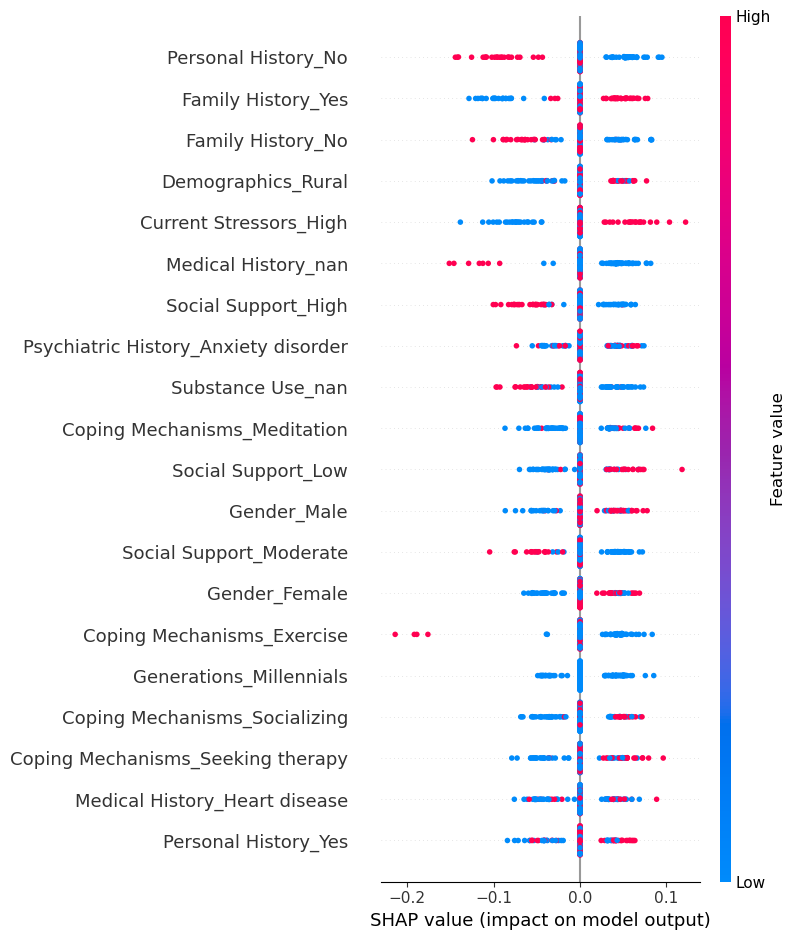


[XAI] Processing Generation: Millennials


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 537us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 549us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 537us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 516us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 516us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 540us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 552us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 540us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 540us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 544us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 546us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 521us/step
1/1 

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\223726349.py:74: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(vals_to_plot, X_gen_matrix, feature_names=feature_names, show=False)


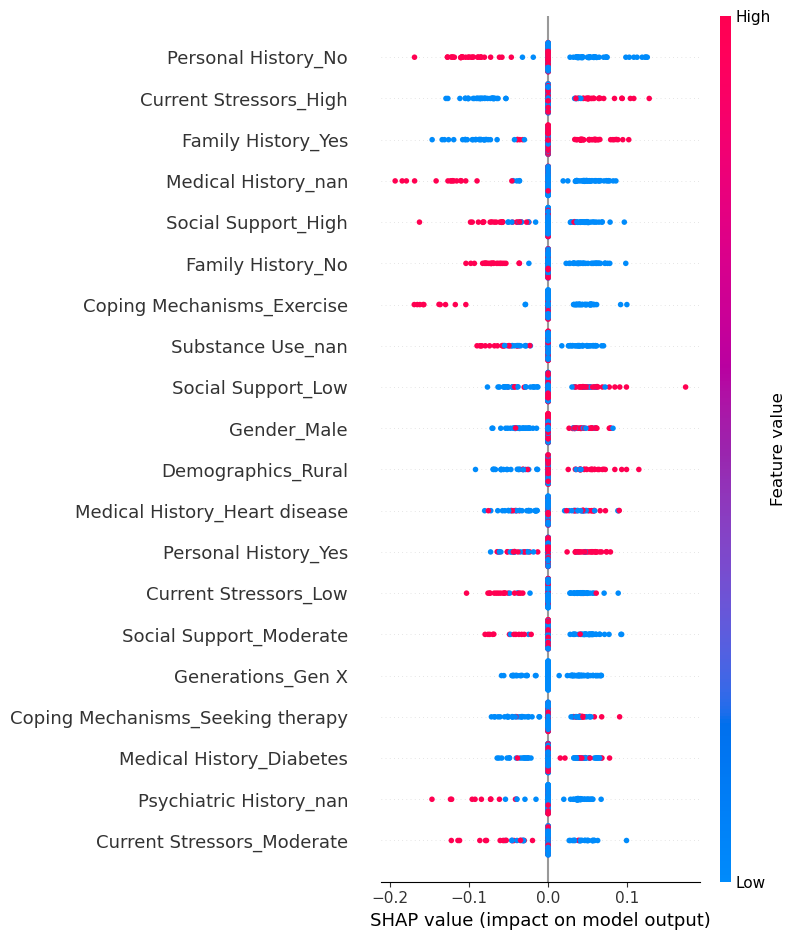


[XAI] Processing Generation: Gen X


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 592us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 567us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 593us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 627us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 604us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 579us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 546us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 546us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 515us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 527us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 555us/step
1/1 

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\223726349.py:74: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(vals_to_plot, X_gen_matrix, feature_names=feature_names, show=False)


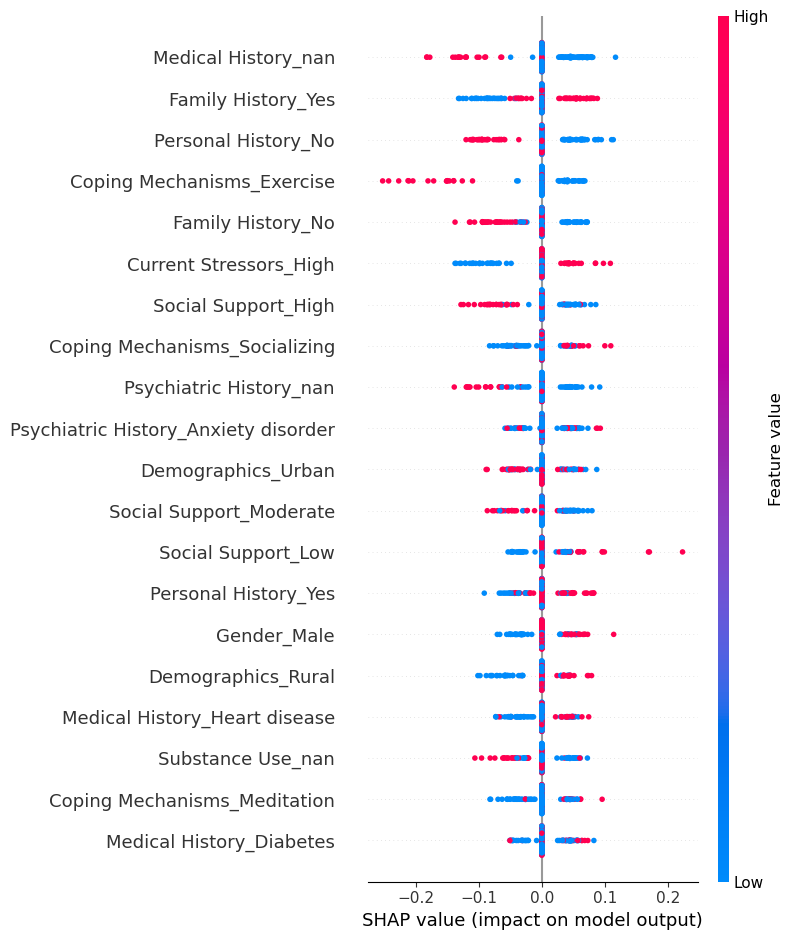


[XAI] Processing Generation: Boomers


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 518us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 530us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 551us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 589us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 582us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 566us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 558us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 552us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 593us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 544us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 554us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1658/1658 ━━━━━━━━━━━━━━━━━━━━ 1s 627us/step
1/1 

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\223726349.py:74: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(vals_to_plot, X_gen_matrix, feature_names=feature_names, show=False)


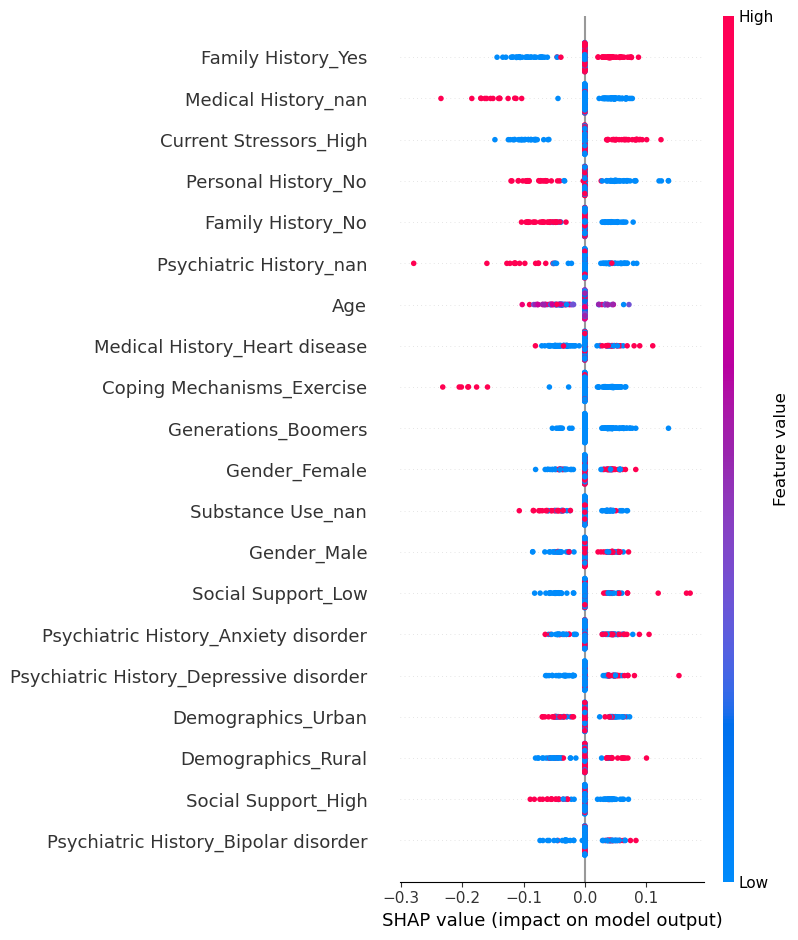

In [52]:
# ============================================================
# PART 6: XAI SPLICED BY GENERATION (OCCURRENCE MODEL)
# ============================================================
import shap
import numpy as np # Ensure numpy is imported
print("\n" + "="*60)
print("STARTING XAI SHAP ANALYSIS FOR OCCURRENCE (By Generation)")
print("="*60)

# 1. Define Generation Logic
def get_generation(age):
    if pd.isna(age): return "Unknown"
    if age <= 26: return "Gen Z"
    elif age <= 42: return "Millennials"
    elif age <= 58: return "Gen X"
    else: return "Boomers"

# 2. Prepare Data
try:
    feature_names = pre_occ.get_feature_names_out()
    feature_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]
except:
    feature_names = [f"Feat {i}" for i in range(X_test_ann.shape[1])]

xai_df = pd.DataFrame(X_test_ann, columns=feature_names)
xai_df['Generations'] = test_df['Age'].apply(get_generation).values

# 3. Initialize SHAP with the renamed model (final_best_ann_occ)
print("[XAI] Initializing SHAP Explainer...")
background_sample = shap.sample(X_train_ann, 100) 

# --- ROBUST PREDICTION FUNCTION (THE FIX) ---
def predict_proba_fn(x):
    # Get predictions
    preds = final_best_ann_occ.predict_proba(x)
    preds = np.array(preds) # Ensure it's a numpy array
    
    # Case A: 1D Array (n_samples,) -> This caused the error before
    # These are already probabilities for the positive class
    if preds.ndim == 1:
        return preds
        
    # Case B: 2D Array with 1 column (n_samples, 1) -> Sigmoid output
    if preds.shape[1] == 1:
        return preds.ravel()
        
    # Case C: 2D Array with 2 columns (n_samples, 2) -> [Prob_0, Prob_1]
    # We return the second column (Class 1)
    if preds.shape[1] == 2:
        return preds[:, 1]
        
    return preds.ravel() # Fallback

explainer = shap.KernelExplainer(predict_proba_fn, background_sample)

# 4. Plot per Generation
gen_order = ['Gen Z', 'Millennials', 'Gen X', 'Boomers']
for gen in gen_order:
    print(f"\n[XAI] Processing Generation: {gen}")
    gen_data = xai_df[xai_df['Generations'] == gen].drop(columns=['Generations'])
    X_gen_matrix = gen_data.values
    
    if len(X_gen_matrix) == 0: continue
    
    # Subsample for speed
    if len(X_gen_matrix) > 200: X_gen_matrix = X_gen_matrix[:200]

    shap_values = explainer.shap_values(X_gen_matrix)
    
    plt.figure(figsize=(10, 6))
    plt.title(f"Factors Triggering Panic Attacks: {gen} (Occurrence)")
    
    vals_to_plot = shap_values[0] if isinstance(shap_values, list) else shap_values
    shap.summary_plot(vals_to_plot, X_gen_matrix, feature_names=feature_names, show=False)
    plt.show()

### ------***Artificial Neural Network (ANN) - Severity Model***------

In [53]:
# ============================================================
# Unified ANN Severity Model (Predicts 1, 2, 3) - Setup
# ============================================================

# --- 1. Prepare Full Training Data ---
# We use the FULL train_df (Diagnosis 0 AND 1).
EXCLUDE_SEV = {
    PAS_LABEL_COL,                  # Target
    DIAGNOSIS_COL,                  # Occurrence Target
    'Severity_Category',            # Direct leak
    'Composite_Severity_Index',     # Direct leak
    'Severity', 
    # 'Impact on Life',   # Leaky inputs
    'Symptoms',
    PAO_LABEL_COL, PAO_PROBA_COL,   # Placeholders
    PAS_PROBA_COL                   # Placeholder
}

FEATURE_COLS = [c for c in train_df.columns if c not in EXCLUDE_SEV]

X_train_all = train_df[FEATURE_COLS].copy()
y_train_all = train_df[PAS_LABEL_COL].astype(int) # Classes: 1, 2, 3

X_test_all  = test_df.reindex(columns=FEATURE_COLS).copy()
y_test_all  = test_df[PAS_LABEL_COL].astype(int)

# --- 2. Encode Features (StandardScaler is better for ANN) ---
num_cols = X_train_all.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train_all.select_dtypes(include=['object']).columns.tolist()

# Use StandardScaler for numeric cols to help ANN convergence
preprocessor_ann = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

X_train_all_enc = preprocessor_ann.fit_transform(X_train_all)
X_test_all_enc  = preprocessor_ann.transform(X_test_all)

# --- 3. Apply SMOTE (Balance 1, 2, and 3) ---
print("\n[ANN SEV] Applying SMOTE to balance classes {1, 2, 3}...")
print(f"Original Counts: {dict(zip(*np.unique(y_train_all, return_counts=True)))}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_all_enc, y_train_all)

print(f"SMOTE Counts:    {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")

# --- 4. Prepare Data for Keras/TensorFlow ---

# A. Transform Target Labels to One-Hot Encoding 
# First Map {1, 2, 3} -> {0, 1, 2}
le = LabelEncoder()
y_train_le = le.fit_transform(y_train_smote)
y_test_le  = le.transform(y_test_all)

# Then Convert to binary class matrix (One-Hot) for 'categorical_crossentropy'
y_train_ann_sev = to_categorical(y_train_le, num_classes=3)
y_test_ann_sev  = to_categorical(y_test_le, num_classes=3)

# B. Ensure Features are Float32
X_train_ann_sev = X_train_smote.astype('float32')
X_test_ann_sev  = X_test_all_enc.astype('float32')

print("\n[ANN SEV] Data Preparation Complete")
print(f"X_train shape: {X_train_ann_sev.shape} (Float32)")
print(f"y_train shape: {y_train_ann_sev.shape} (One-Hot)")
print(f"Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")


[ANN SEV] Applying SMOTE to balance classes {1, 2, 3}...
Original Counts: {1: 3245, 2: 2700, 3: 2625}
SMOTE Counts:    {1: 3245, 2: 3245, 3: 3245}

[ANN SEV] Data Preparation Complete
X_train shape: (9735, 36) (Float32)
y_train shape: (9735, 3) (One-Hot)
Class mapping: {1: 0, 2: 1, 3: 2}


#OG CODE

ANN Severity Data:
  SMOTE Train X: (9735, 36), y: (9735,)
  Orig Train X : (8570, 36), y: (8570,)
  Test X       : (2143, 36), y: (2143,)

1. Starting Randomized Search Hyperparameter Tuning (ANN Severity)...
Fitting 10 folds for each of 30 candidates, totalling 300 fits


c:\Users\Moko_\anaconda3\envs\panicml\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\Moko_\anaconda3\envs\panicml\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the train scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Total Tuning Time: 557.14 seconds

[ANN SEVERITY][TUNING] Per-run CV table (sorted by F1 rank):
 run  rank_f1  units1  units2  units3 dropout     l2     lr  epochs  batch_size accuracy precision recall     f1 roc_auc test_log_loss mean_fit_time
  11        1      90      64      20  0.2000 0.0001 0.0005      80         128   0.8110    0.8092 0.8110 0.8087     nan           nan         42.47
  30        2     128      32      16  0.2000 0.0000 0.0020      50         256   0.8089    0.8088 0.8089 0.8073     nan           nan         15.00
   8        3     128      32      16  0.1000 0.0001 0.0010      50         128   0.8082    0.8081 0.8082 0.8069     nan           nan         27.88
  26        4     128      45      20  0.1000 0.0000 0.0005      50         256   0.8078    0.8062 0.8078 0.8059     nan           nan         22.27
  23        5     128      45      20  0.2000 0.0001 0.0020      80         256   0.8050    0.8048 0.8050 0.8037     nan           nan         28.94
  20      

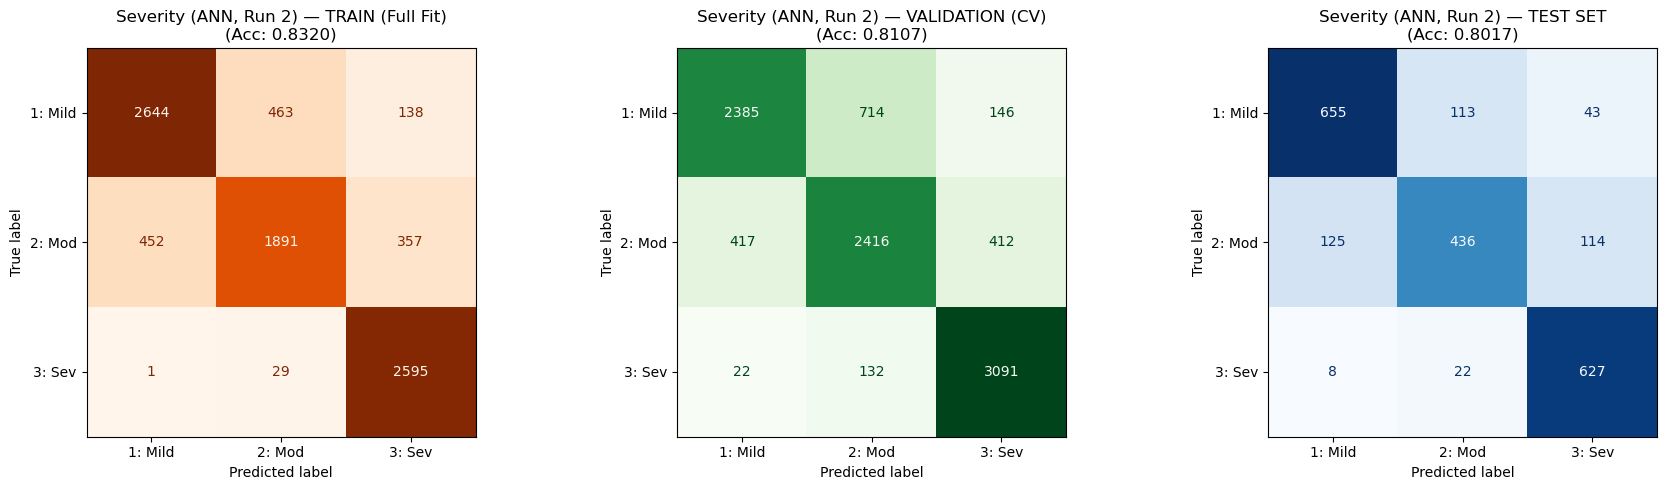

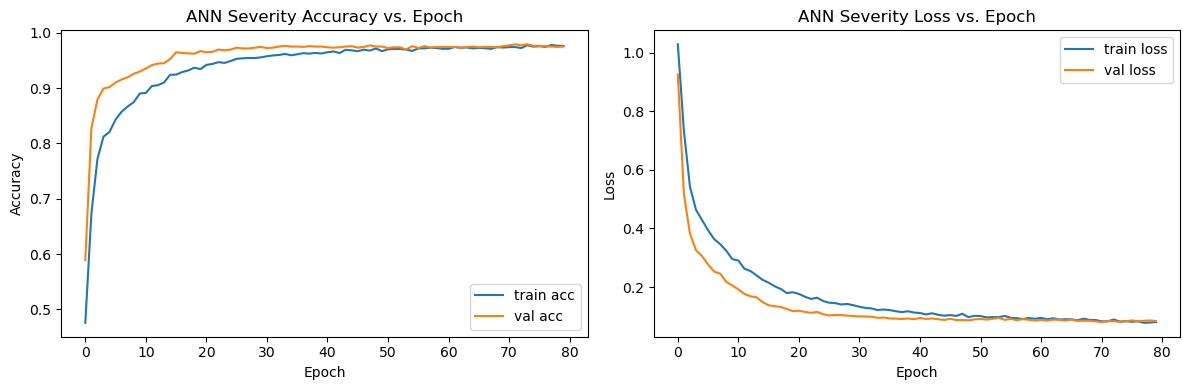


[ANN SEVERITY][BEST RUN 2] Training tuned Keras model for epoch-wise curves...


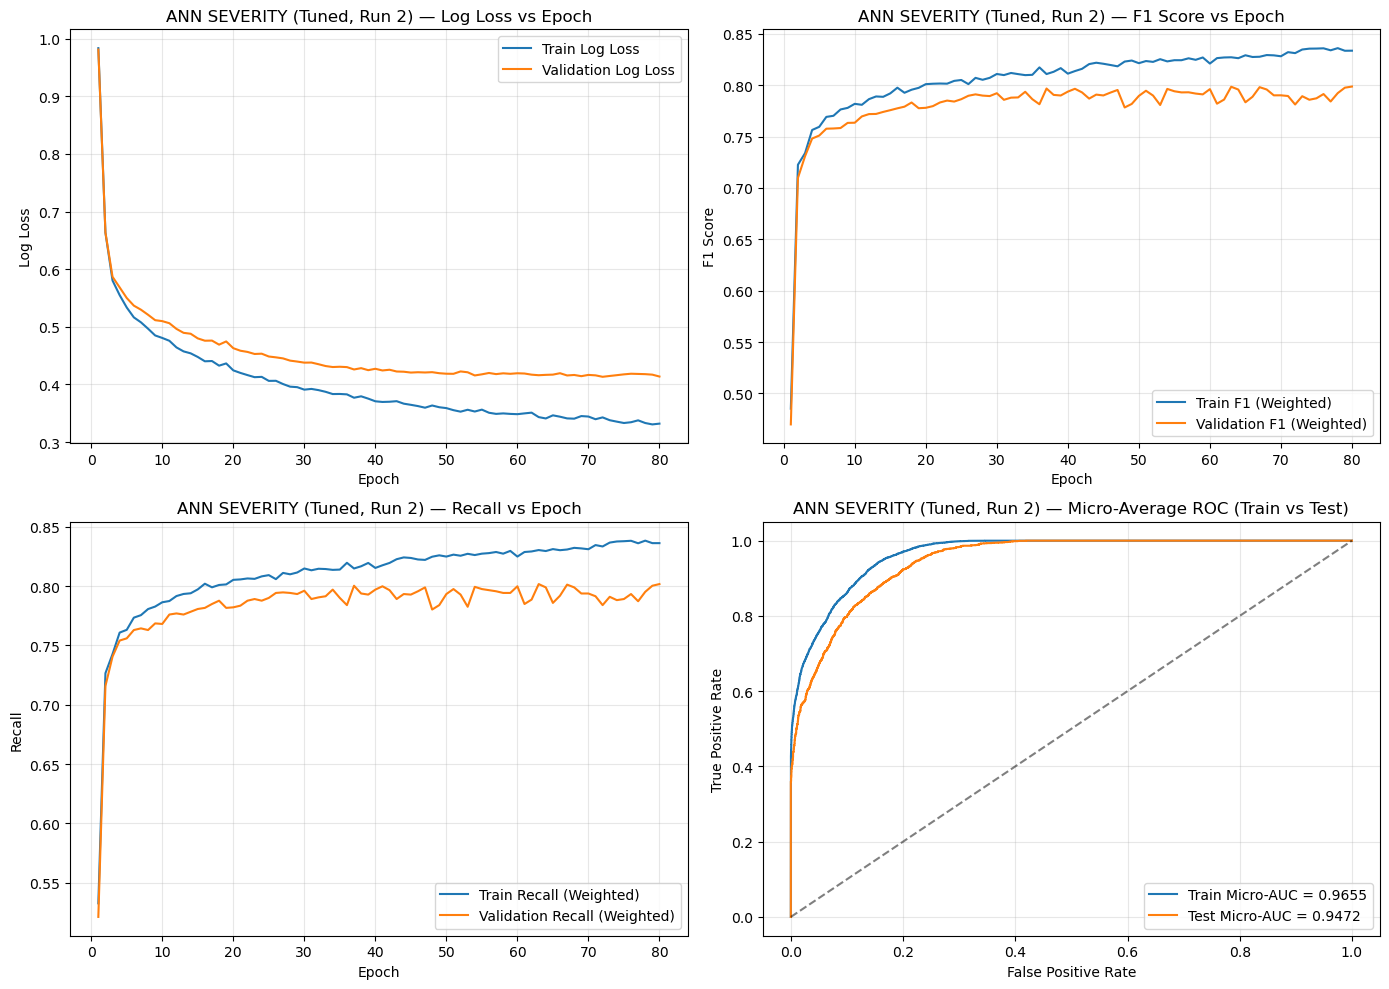

In [54]:
# ============================================================
# ANN — Unified Severity (10-fold CV + Hyperparameter Tuning)
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Keras / TensorFlow ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
# 
from scikeras.wrappers import KerasClassifier
from sklearn.base import clone

# --- Sklearn imports (mirroring RF Severity style) ---
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate,
    cross_val_predict,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from imblearn.over_sampling import SMOTE  # (if needed elsewhere)

# ============================================================
# 0. DATA SETUP (Severity)
# ============================================================
# Assumes the following are already defined:
# X_train_smote, y_train_smote  -> SMOTE-resampled training data (labels: 1,2,3)
# X_train_all_enc, y_train_all  -> Original training data (no SMOTE)
# X_test_all_enc,  y_test_all   -> Hold-out test set

X_train_smote_ann = X_train_smote.astype("float32")
X_train_all_ann   = X_train_all_enc.astype("float32")
X_test_all_ann    = X_test_all_enc.astype("float32")

# IMPORTANT: keep labels as 1D integers (no one-hot)
y_train_smote_ann = np.asarray(y_train_smote, dtype=int)  # e.g. [1,2,3,...]
y_train_all_ann   = np.asarray(y_train_all, dtype=int)
y_test_all_ann    = np.asarray(y_test_all, dtype=int)

classes = sorted(np.unique(y_train_smote_ann))  # [1,2,3]
num_classes = len(classes)
input_dim = X_train_smote_ann.shape[1]

print("ANN Severity Data:")
print(f"  SMOTE Train X: {X_train_smote_ann.shape}, y: {y_train_smote_ann.shape}")
print(f"  Orig Train X : {X_train_all_ann.shape}, y: {y_train_all_ann.shape}")
print(f"  Test X       : {X_test_all_ann.shape}, y: {y_test_all_ann.shape}")

# ============================================================
# 0. LOAD SHARED SEVERITY CV FOLDS (same as Hybrid Severity)
# ============================================================
# This file should have been created once using the same
# X_train_smote / y_train_smote ordering used here.
severity_folds = np.load("severity_cv_folds.npy", allow_pickle=True)
cv_folds = [(f["train"], f["val"]) for f in severity_folds]
n_val_samples_folds = [len(f[1]) for f in cv_folds]

# ============================================================
# 1. Model Definition (Multiclass ANN)
# ============================================================
def build_sev_ann(input_dim,
                  num_classes=3,
                  units1=90, units2=45, units3=20,
                  dropout=0.0, l2=0.0, lr=1e-3):

    reg = regularizers.l2(l2) if l2 and l2 > 0 else None

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(units1, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout) if dropout > 0 else layers.Activation("linear"),
        layers.Dense(units2, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout) if dropout > 0 else layers.Activation("linear"),
        layers.Dense(units3, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout) if dropout > 0 else layers.Activation("linear"),
        layers.Dense(num_classes, activation="softmax")
    ])

    # Using sparse_categorical_crossentropy with integer labels 1,2,3
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# Wrap with SciKeras; hyperparameters will be overridden by tuning
clf = KerasClassifier(
    model=build_sev_ann,
    model__input_dim=input_dim,
    model__num_classes=num_classes,
    epochs=50,
    batch_size=256,
    verbose=0,
    validation_split=0.0,   # no internal val split during CV/tuning
    shuffle=True,
    callbacks=None,
    random_state=42,
)

# Common 10-fold CV object (like RF Severity)
# cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# Use the shared folds for all CV (tuning + final) so ANN & Hybrid line up
cv = cv_folds

# Multiclass scoring (mirrors RF Severity: weighted averages + OVR AUC)
scoring = {
    "f1":        "f1_weighted",
    "accuracy":  "accuracy",
    "precision": "precision_weighted",
    "recall":    "recall_weighted",
    "roc_auc":   "roc_auc_ovr_weighted",
    "log_loss":  "neg_log_loss",
}

# Hyperparameter distributions (for ANN)
param_distributions = {
    "model__units1":   [64, 90, 128],
    "model__units2":   [32, 45, 64],
    "model__units3":   [16, 20, 32],
    "model__dropout":  [0.0, 0.1, 0.2],       # slightly milder dropout
    "model__l2":       [0.0, 1e-5, 1e-4],     # mild L2 only
    "model__lr":       [5e-4, 1e-3, 2e-3],
    "epochs":          [50, 80],
    "batch_size":      [128, 256],
}

# ============================================================
# 2. Hyperparameter Tuning (RandomizedSearchCV)
# ============================================================
print("\n========================================================")
print("1. Starting Randomized Search Hyperparameter Tuning (ANN Severity)...")
print("========================================================")

random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=30,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    refit="f1",
    verbose=1,
    random_state=42,
    return_train_score=True,
)

t0 = time.time()
random_search.fit(X_train_smote_ann, y_train_smote_ann)
tuning_time = time.time() - t0
print(f"Total Tuning Time: {tuning_time:.2f} seconds")

# --- 2b. Per-run tuning table (RF-style) ---
cv_results_tuning = random_search.cv_results_
df = pd.DataFrame(cv_results_tuning)

# Flip sign of log_loss
df["mean_test_log_loss_pos"] = -df["mean_test_log_loss"]

cols = [
    "rank_test_f1",
    "param_model__units1", "param_model__units2", "param_model__units3",
    "param_model__dropout", "param_model__l2", "param_model__lr",
    "param_epochs", "param_batch_size",
    "mean_test_accuracy", "mean_test_precision", "mean_test_recall",
    "mean_test_f1", "mean_test_roc_auc", "mean_test_log_loss_pos", "mean_fit_time"
]

results_table = df[cols].copy()
results_table.columns = [
    "rank_f1", "units1", "units2", "units3",
    "dropout", "l2", "lr",
    "epochs", "batch_size",
    "accuracy", "precision", "recall",
    "f1", "roc_auc", "test_log_loss", "mean_fit_time"
]

results_table.insert(0, "run", np.arange(1, len(results_table) + 1))
results_table = results_table.sort_values("rank_f1")

print("\n[ANN SEVERITY][TUNING] Per-run CV table (sorted by F1 rank):")
results_table_display = results_table.copy()
float_cols_disp = results_table_display.select_dtypes(include=[np.float64]).columns
for col in float_cols_disp:
    if col != "mean_fit_time":
        results_table_display[col] = results_table_display[col].apply(lambda x: f"{x:.4f}")
results_table_display["mean_fit_time"] = results_table_display["mean_fit_time"].apply(lambda x: f"{x:.2f}")
print(results_table_display.to_string(index=False))

best_params = random_search.best_params_
print("\n[ANN SEVERITY][TUNING] Best parameters found by RandomizedSearchCV:")
print(best_params)
print(f"[ANN SEVERITY][TUNING] Best mean CV F1 (Weighted): {random_search.best_score_:.4f}")

best_ann_base = random_search.best_estimator_

# ============================================================
# 3. Run Best Model 3 Times with 10-Fold CV (SMOTE data)
# ============================================================
print("\n========================================================")
print("4. Final Validation: Running tuned ANN 3 times (10-fold CV on SMOTE data)...")
print("========================================================")

RUNS = 3
all_runs_metrics = []
best_cv_f1_score = -1
best_run_cv_metrics = {}
best_run_cv_results = None
best_run_model_params = None

for i in range(1, RUNS + 1):
    current_random_state = 100 + i

    ann_run = clone(best_ann_base)
    ann_run.set_params(random_state=current_random_state)

    print(f"--> Starting Run {i} (random_state={current_random_state})...")

    t_start_cv = time.time()
    cv_results = cross_validate(
        estimator=ann_run,
        X=X_train_smote_ann,
        y=y_train_smote_ann,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
    )
    cv_total_time = time.time() - t_start_cv

    mean_f1 = np.mean(cv_results["test_f1"])

    metrics = {
        "Run": i,
        "Accuracy": np.mean(cv_results["test_accuracy"]),
        "Precision": np.mean(cv_results["test_precision"]),
        "Recall": np.mean(cv_results["test_recall"]),
        "F1-Score": mean_f1,
        "ROC-AUC": np.mean(cv_results["test_roc_auc"]),
        "Train Time (s)": np.mean(cv_results["fit_time"]),
        "Total CV Time (s)": cv_total_time,
        "random_state": current_random_state,
    }
    all_runs_metrics.append(metrics)

    if mean_f1 > best_cv_f1_score:
        best_cv_f1_score = mean_f1
        best_run_cv_metrics = metrics
        best_run_cv_results = cv_results
        best_run_model_params = ann_run.get_params()

metrics_df = pd.DataFrame(all_runs_metrics)

print("\n[ANN SEVERITY] Mean 10-Fold CV Performance (3 Independent Runs on SMOTE Data):")
metrics_df_display = metrics_df.drop(columns=["random_state"]).copy()
float_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
for col in float_cols:
    metrics_df_display[col] = metrics_df_display[col].apply(lambda x: f"{x:.4f}")
time_cols = ["Train Time (s)", "Total CV Time (s)"]
for col in time_cols:
    metrics_df_display[col] = metrics_df_display[col].apply(lambda x: f"{x:.2f}")
print(metrics_df_display.to_string(index=False))

avg_metrics = metrics_df[float_cols + ["Train Time (s)", "Total CV Time (s)"]].mean()
print("\n[ANN SEVERITY] Average Metrics Across the 3 Runs:")
avg_table_data = {
    "Metric": avg_metrics.index,
    "Average Value": [f"{v:.4f}" if m in float_cols else f"{v:.2f}" for m, v in avg_metrics.items()],
}
avg_metrics_df = pd.DataFrame(avg_table_data)
print(avg_metrics_df.to_string(index=False))

# ============================================================
# 4. Finalize and Plot Best Run Results (Gold-Standard Format)
# ============================================================
if best_run_cv_metrics:
    best_run_index = best_run_cv_metrics["Run"]
    best_run_f1 = best_run_cv_metrics["F1-Score"]

    # ------------------------------------------------------------
    # [H2] Per-Fold Metrics for ANN SEVERITY (10-Fold CV, Best Run)
    # ------------------------------------------------------------
    ann_sev_cv_results = pd.DataFrame({
        "model_name": ["ANN_SEV"] * len(cv_folds),
        "fold_id": np.arange(1, len(cv_folds) + 1),
        "accuracy_weighted":  best_run_cv_results["test_accuracy"],
        "precision_weighted": best_run_cv_results["test_precision"],
        "recall_weighted":    best_run_cv_results["test_recall"],
        "f1_weighted":        best_run_cv_results["test_f1"],
        "roc_auc_weighted":   best_run_cv_results["test_roc_auc"],
        "n_val_samples":      n_val_samples_folds,
    })

    print("\n[H2] ANN SEV — Per-Fold Metrics (10-Fold CV on SMOTE Training Set):")
    print(ann_sev_cv_results.to_string(index=False))

    # Arrays for statistical comparison vs HYBRID SEVERITY
    ann_sev_f1_folds   = ann_sev_cv_results["f1_weighted"].values
    ann_sev_acc_folds  = ann_sev_cv_results["accuracy_weighted"].values
    ann_sev_auc_folds  = ann_sev_cv_results["roc_auc_weighted"].values
    ann_sev_rec_folds  = ann_sev_cv_results["recall_weighted"].values
    ann_sev_prec_folds = ann_sev_cv_results["precision_weighted"].values

    print("\n========================================================")
    print(f"5. Analyzing Best CV Run (Run {best_run_index}) with Avg CV F1: {best_run_f1:.4f}")
    print("========================================================")

    # # 1. Train best ANN on FULL SMOTE training set
    # final_best_ann = clone(best_ann_base)
    # final_best_ann.set_params(**best_run_model_params)
    # t_start_train = time.time()
    # final_best_ann.fit(X_train_smote_ann, y_train_smote_ann)
    # final_train_time = time.time() - t_start_train

    # 1. Train best ANN on FULL SMOTE training set
    final_best_ann_sev = clone(best_ann_base)
    final_best_ann_sev.set_params(**best_run_model_params)

    # Use a validation split *only* for the final training so we can plot val curves
    final_best_ann_sev.set_params(validation_split=0.15)
    t_start_train = time.time()
    final_best_ann_sev.fit(X_train_smote_ann, y_train_smote_ann)
    final_train_time = time.time() - t_start_train


    # 2. Evaluate on ORIGINAL TRAIN and TEST sets
    # TRAIN (Original data)
    proba_train_best = final_best_ann_sev.predict_proba(X_train_all_ann)
    y_pred_train_best = final_best_ann_sev.predict(X_train_all_ann)

    # TEST (Hold-out)
    t_start_eval = time.time()
    proba_test_best = final_best_ann_sev.predict_proba(X_test_all_ann)
    y_pred_test_best = final_best_ann_sev.predict(X_test_all_ann)
    final_eval_time = time.time() - t_start_eval

    # ---- Train Metrics (Full Fit on Original Data) ----
    tr_acc = accuracy_score(y_train_all_ann, y_pred_train_best)
    tr_prec = precision_score(y_train_all_ann, y_pred_train_best, average="weighted", zero_division=0)
    tr_rec = recall_score(y_train_all_ann, y_pred_train_best, average="weighted", zero_division=0)
    tr_f1 = f1_score(y_train_all_ann, y_pred_train_best, average="weighted", zero_division=0)
    y_train_bin = label_binarize(y_train_all_ann, classes=classes)
    tr_auc = roc_auc_score(y_train_bin, proba_train_best, multi_class="ovr", average="weighted")

    # ---- Test Metrics (Hold-Out) ----
    te_acc = accuracy_score(y_test_all_ann, y_pred_test_best)
    te_prec = precision_score(y_test_all_ann, y_pred_test_best, average="weighted", zero_division=0)
    te_rec = recall_score(y_test_all_ann, y_pred_test_best, average="weighted", zero_division=0)
    te_f1 = f1_score(y_test_all_ann, y_pred_test_best, average="weighted", zero_division=0)
    y_test_bin = label_binarize(y_test_all_ann, classes=classes)
    te_auc = roc_auc_score(y_test_bin, proba_test_best, multi_class="ovr", average="weighted")

    cv_results = best_run_cv_results
    train_time_ann_sev = final_train_time
    eval_time_ann_sev = final_eval_time

    # ----------------- Gold Standard Comparison Table -----------------
    print("\n" + "="*85)
    print(f"{'METRIC':<15} | {'TRAIN (Full Fit)':<18} | {'VALIDATION (10-Fold)':<20} | {'TEST (Hold-out)':<18}")
    print("-" * 85)
    print(f"{'Accuracy':<15} | {tr_acc:<18.4f} | {cv_results['test_accuracy'].mean():<20.4f} | {te_acc:<18.4f}")
    print(f"{'Precision':<15} | {tr_prec:<18.4f} | {cv_results['test_precision'].mean():<20.4f} | {te_prec:<18.4f}")
    print(f"{'Recall':<15} | {tr_rec:<18.4f} | {cv_results['test_recall'].mean():<20.4f} | {te_rec:<18.4f}")
    print(f"{'F1 Score':<15} | {tr_f1:<18.4f} | {cv_results['test_f1'].mean():<20.4f} | {te_f1:<18.4f}")
    print(f"{'ROC AUC':<15} | {tr_auc:<18.4f} | {cv_results['test_roc_auc'].mean():<20.4f} | {te_auc:<18.4f}")
    print("=" * 85)
    print(f"Total Training Time: {train_time_ann_sev:.2f}s")
    print(f"Total Testing Time:  {eval_time_ann_sev:.2f}s")

    # ============================================================
    # 5. Confusion Matrices (Train vs Validation vs Test)
    # ============================================================
    labels_cm = classes  # [1,2,3]
    display_labels = ['1: Mild', '2: Mod', '3: Sev']

    fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5))

    # TRAIN (Full Fit on Original)
    cm_train = confusion_matrix(y_train_all_ann, y_pred_train_best, labels=labels_cm)
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=display_labels)
    disp_train.plot(ax=axes_cm[0], values_format='d', colorbar=False, cmap='Oranges')
    axes_cm[0].set_title(f"Severity (ANN, Run {best_run_index}) — TRAIN (Full Fit)\n(Acc: {tr_acc:.4f})")

    # VALIDATION (CV on SMOTE data) via cross_val_predict
    print("\nGenerating CV Predictions for ANN Severity Matrix...")
    ann_cv = clone(best_ann_base)
    ann_cv.set_params(**best_run_model_params)
    y_pred_cv = cross_val_predict(
        ann_cv,
        X_train_smote_ann,
        y_train_smote_ann,
        cv=cv,
        n_jobs=-1,
    )
    cm_cv = confusion_matrix(y_train_smote_ann, y_pred_cv, labels=labels_cm)
    disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=display_labels)
    disp_cv.plot(ax=axes_cm[1], values_format='d', colorbar=False, cmap='Greens')
    axes_cm[1].set_title(
        f"Severity (ANN, Run {best_run_index}) — VALIDATION (CV)\n"
        f"(Acc: {cv_results['test_accuracy'].mean():.4f})"
    )

    # TEST (Hold-Out)
    cm_test = confusion_matrix(y_test_all_ann, y_pred_test_best, labels=labels_cm)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=display_labels)
    disp_test.plot(ax=axes_cm[2], values_format='d', colorbar=False, cmap='Blues')
    axes_cm[2].set_title(f"Severity (ANN, Run {best_run_index}) — TEST SET\n(Acc: {te_acc:.4f})")

    plt.tight_layout()
    plt.show()

        # === STANDARD TRAINING CURVES (Accuracy & Loss vs Epoch) ===
    # SciKeras exposes training history via .history_
    hist = getattr(final_best_ann, "history_", None)

    if hist is not None:
        # history_ is usually a pandas DataFrame; convert to dict of lists
        if hasattr(hist, "to_dict"):
            hist_dict = hist.to_dict(orient="list")
        elif hasattr(hist, "history"):
            hist_dict = hist.history
        elif isinstance(hist, dict):
            hist_dict = hist
        else:
            hist_dict = {}
    else:
        hist_dict = {}

    if hist_dict:
        fig_ep, axes_ep = plt.subplots(1, 2, figsize=(12, 4))

        # Accuracy vs Epoch
        train_acc = hist_dict.get("accuracy", [])
        val_acc   = hist_dict.get("val_accuracy", [])
        axes_ep[0].plot(train_acc, label="train acc")
        if len(val_acc) > 0:
            axes_ep[0].plot(val_acc, label="val acc")
        axes_ep[0].set_xlabel("Epoch")
        axes_ep[0].set_ylabel("Accuracy")
        axes_ep[0].set_title("ANN Severity Accuracy vs. Epoch")
        axes_ep[0].legend()

        # Loss vs Epoch
        train_loss = hist_dict.get("loss", [])
        val_loss   = hist_dict.get("val_loss", [])
        axes_ep[1].plot(train_loss, label="train loss")
        if len(val_loss) > 0:
            axes_ep[1].plot(val_loss, label="val loss")
        axes_ep[1].set_xlabel("Epoch")
        axes_ep[1].set_ylabel("Loss")
        axes_ep[1].set_title("ANN Severity Loss vs. Epoch")
        axes_ep[1].legend()

        plt.tight_layout()
        plt.show()

    # ============================================================
    # 6. Metric Curves vs Epoch (Log Loss, F1, Recall) + ROC
    # ============================================================
    print(f"\n[ANN SEVERITY][BEST RUN {best_run_index}] "
          f"Training tuned Keras model for epoch-wise curves...")

    class EpochMetricsCallback(keras.callbacks.Callback):
        def __init__(self, X_train, y_train, X_val, y_val):
            super().__init__()
            self.X_train = X_train
            self.y_train = np.asarray(y_train)
            self.X_val = X_val
            self.y_val = np.asarray(y_val)

            self.train_losses = []
            self.val_losses = []
            self.train_f1s = []
            self.val_f1s = []
            self.train_recalls = []
            self.val_recalls = []

        def on_epoch_end(self, epoch, logs=None):
            proba_tr = self.model.predict(self.X_train, verbose=0)
            proba_val = self.model.predict(self.X_val,   verbose=0)

            pred_tr = np.argmax(proba_tr, axis=1)
            pred_val = np.argmax(proba_val, axis=1)

            # y_* are 0..2 integers here
            self.train_losses.append(log_loss(self.y_train, proba_tr))
            self.val_losses.append(log_loss(self.y_val,   proba_val))

            self.train_f1s.append(
                f1_score(self.y_train, pred_tr, average="weighted", zero_division=0)
            )
            self.val_f1s.append(
                f1_score(self.y_val,   pred_val, average="weighted", zero_division=0)
            )

            self.train_recalls.append(
                recall_score(self.y_train, pred_tr, average="weighted", zero_division=0)
            )
            self.val_recalls.append(
                recall_score(self.y_val,   pred_val, average="weighted", zero_division=0)
            )

    # Shift labels 1,2,3 -> 0,1,2 for pure Keras training
    y_train_all_zero = y_train_all_ann - 1
    y_test_all_zero  = y_test_all_ann - 1

    keras.backend.clear_session()
    best_keras_ann = build_sev_ann(
        input_dim=input_dim,
        num_classes=num_classes,
        units1=best_params["model__units1"],
        units2=best_params["model__units2"],
        units3=best_params["model__units3"],
        dropout=best_params["model__dropout"],
        l2=best_params["model__l2"],
        lr=best_params["model__lr"],
    )

    epochs_best = best_params.get("epochs", 50)
    batch_best = best_params.get("batch_size", 256)

    epoch_cb = EpochMetricsCallback(
        X_train=X_train_all_ann,
        y_train=y_train_all_zero,
        X_val=X_test_all_ann,
        y_val=y_test_all_zero,
    )

    history_epoch = best_keras_ann.fit(
        X_train_all_ann,
        y_train_all_zero,
        epochs=epochs_best,
        batch_size=batch_best,
        verbose=0,
        callbacks=[epoch_cb],
    )

    # ROC data: Train vs Test (micro-average)
    proba_train_epoch = best_keras_ann.predict(X_train_all_ann, verbose=0)
    proba_test_epoch  = best_keras_ann.predict(X_test_all_ann,  verbose=0)

    fpr_tr, tpr_tr, _ = roc_curve(y_train_bin.ravel(), proba_train_epoch.ravel())
    roc_auc_tr_micro = auc(fpr_tr, tpr_tr)

    fpr_te, tpr_te, _ = roc_curve(y_test_bin.ravel(),  proba_test_epoch.ravel())
    roc_auc_te_micro = auc(fpr_te, tpr_te)

    epochs_range = np.arange(1, len(epoch_cb.train_losses) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Log Loss vs Epoch
    axes[0, 0].plot(epochs_range, epoch_cb.train_losses, label="Train Log Loss")
    axes[0, 0].plot(epochs_range, epoch_cb.val_losses,   label="Validation Log Loss")
    axes[0, 0].set_title(f"ANN SEVERITY (Tuned, Run {best_run_index}) — Log Loss vs Epoch")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Log Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. F1 vs Epoch
    axes[0, 1].plot(epochs_range, epoch_cb.train_f1s, label="Train F1 (Weighted)")
    axes[0, 1].plot(epochs_range, epoch_cb.val_f1s,   label="Validation F1 (Weighted)")
    axes[0, 1].set_title(f"ANN SEVERITY (Tuned, Run {best_run_index}) — F1 Score vs Epoch")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("F1 Score")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Recall vs Epoch
    axes[1, 0].plot(epochs_range, epoch_cb.train_recalls, label="Train Recall (Weighted)")
    axes[1, 0].plot(epochs_range, epoch_cb.val_recalls,   label="Validation Recall (Weighted)")
    axes[1, 0].set_title(f"ANN SEVERITY (Tuned, Run {best_run_index}) — Recall vs Epoch")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Recall")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Micro-average ROC: TRAIN vs TEST
    axes[1, 1].plot(fpr_tr, tpr_tr, label=f"Train Micro-AUC = {roc_auc_tr_micro:.4f}")
    axes[1, 1].plot(fpr_te, tpr_te, label=f"Test Micro-AUC = {roc_auc_te_micro:.4f}")
    axes[1, 1].plot([0, 1], [0, 1], "k--", alpha=0.5)
    axes[1, 1].set_title(
        f"ANN SEVERITY (Tuned, Run {best_run_index}) — Micro-Average ROC (Train vs Test)"
    )
    axes[1, 1].set_xlabel("False Positive Rate")
    axes[1, 1].set_ylabel("True Positive Rate")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("\n[ERROR] No best run data was found to generate ANN Severity plots.")



STARTING XAI SHAP ANALYSIS FOR SEVERITY (By Generation)
[XAI-Sev] Initializing SHAP Explainer...

[XAI-Sev] Processing Generation: Gen Z


  0%|          | 0/200 [00:00<?, ?it/s]

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\2560472947.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


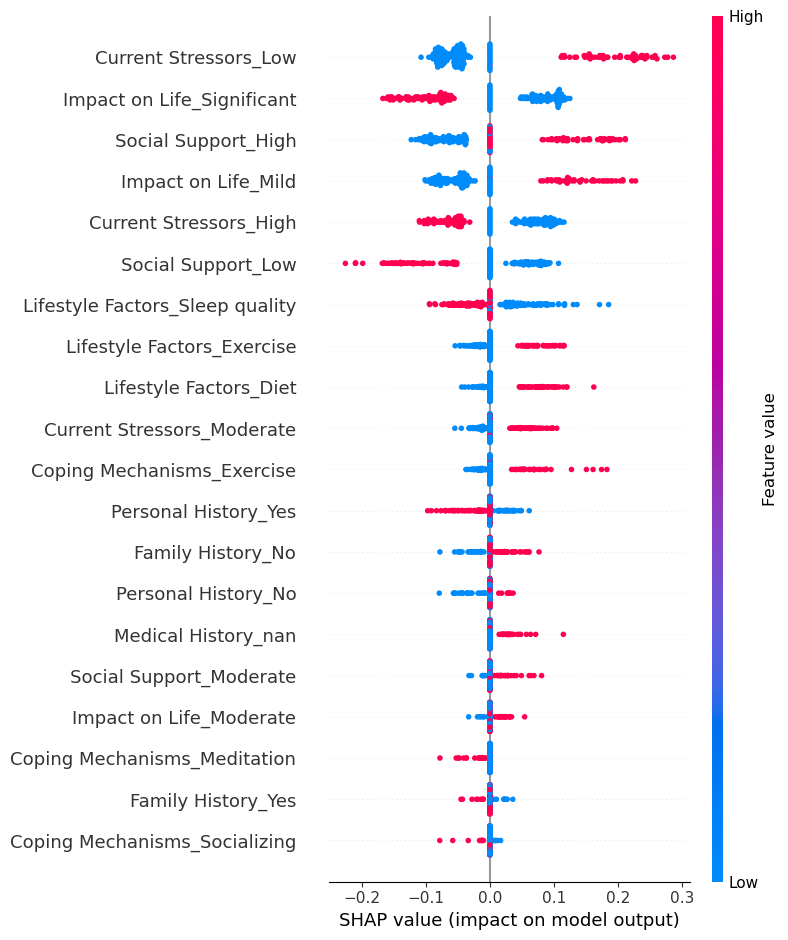

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\2560472947.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


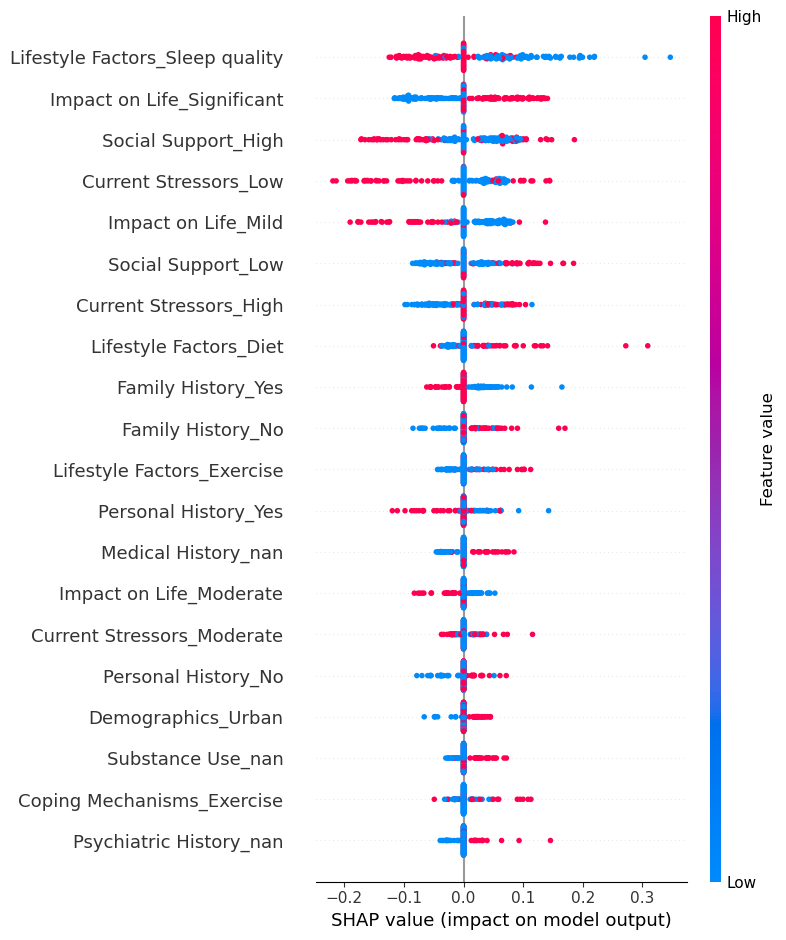

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\2560472947.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


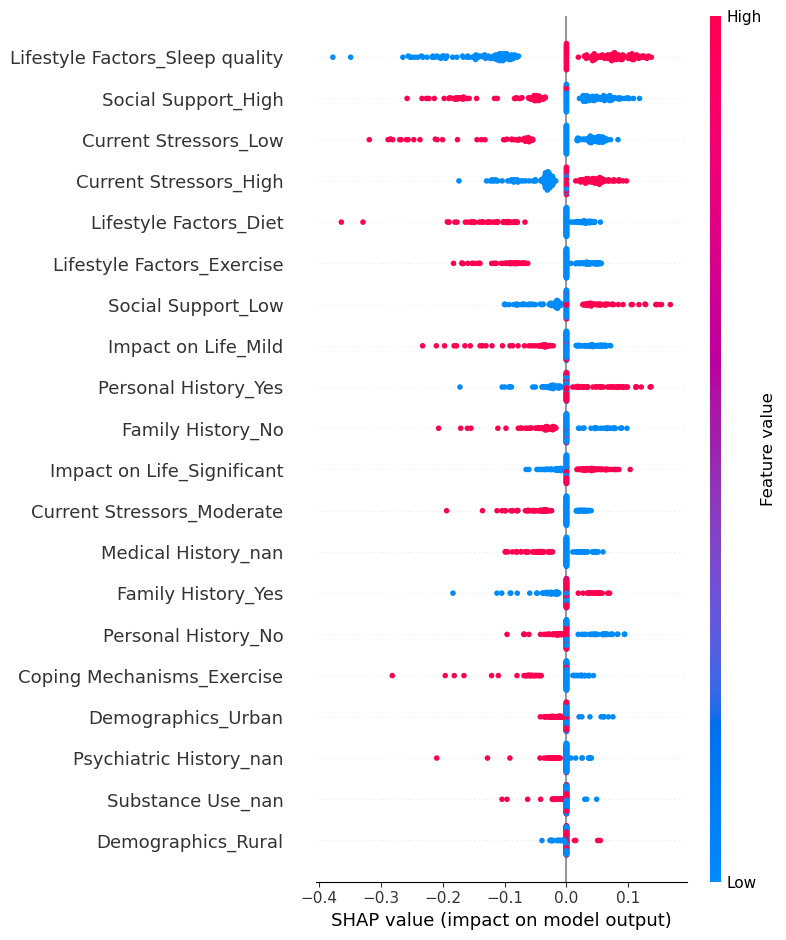


[XAI-Sev] Processing Generation: Millennials


  0%|          | 0/200 [00:00<?, ?it/s]

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\2560472947.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


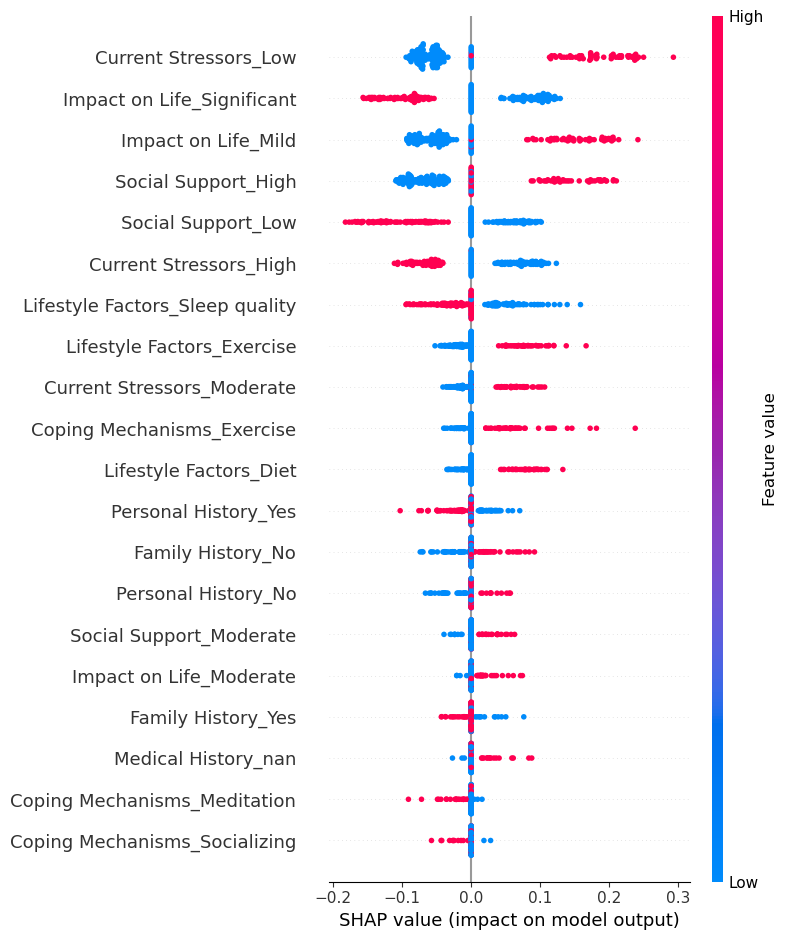

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\2560472947.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


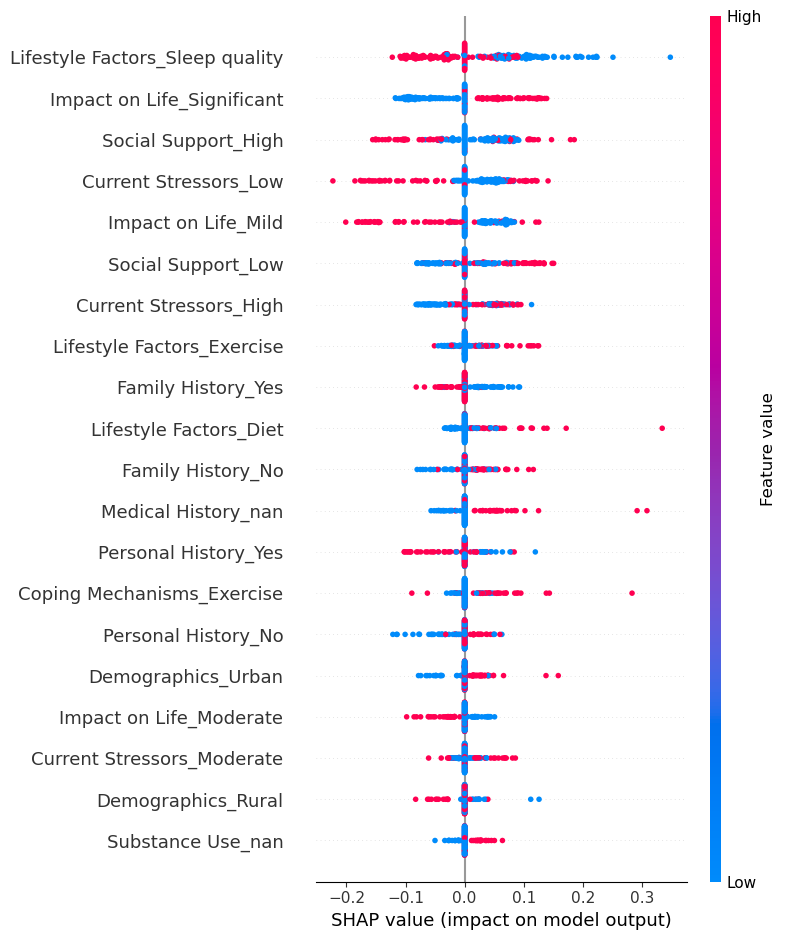

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\2560472947.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


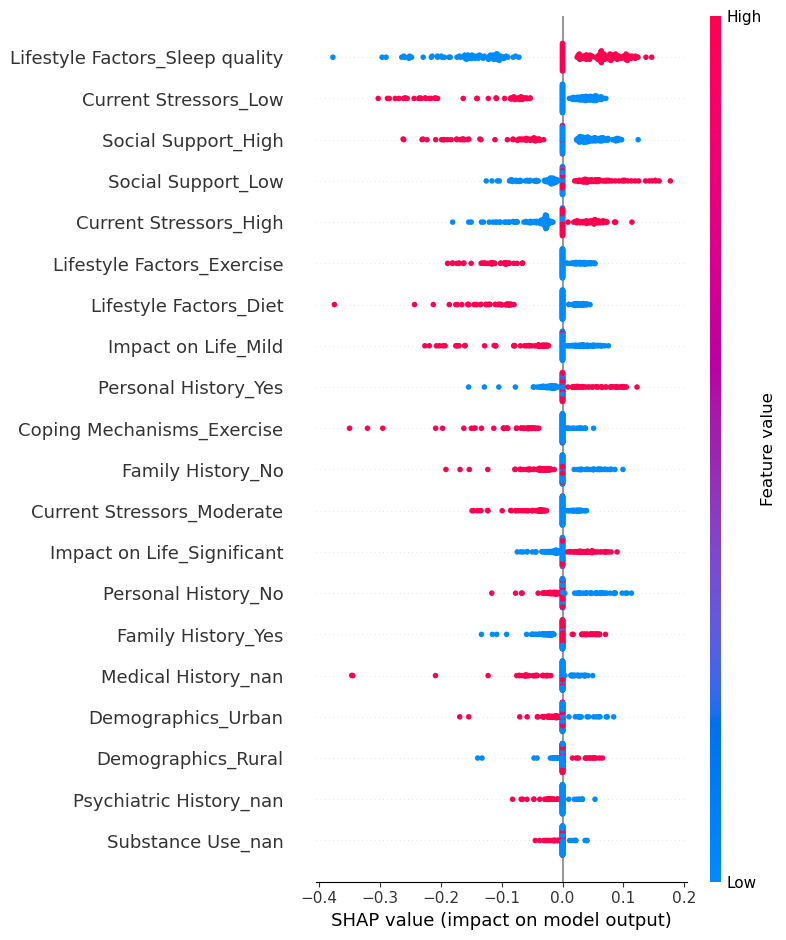


[XAI-Sev] Processing Generation: Gen X


  0%|          | 0/200 [00:00<?, ?it/s]

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\2560472947.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


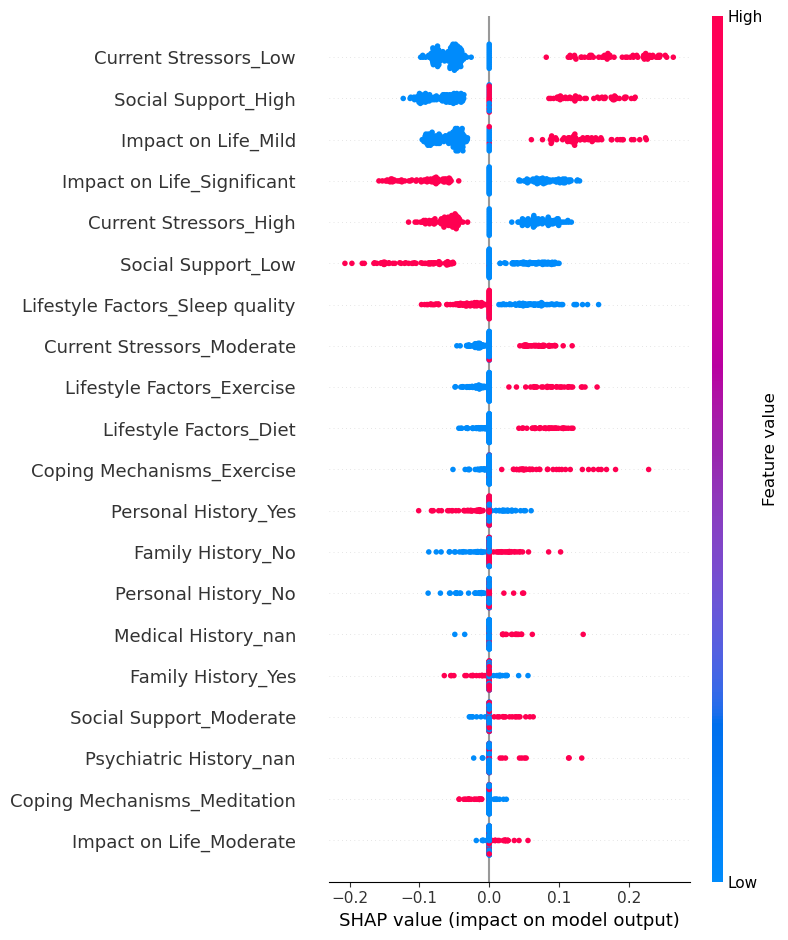

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\2560472947.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


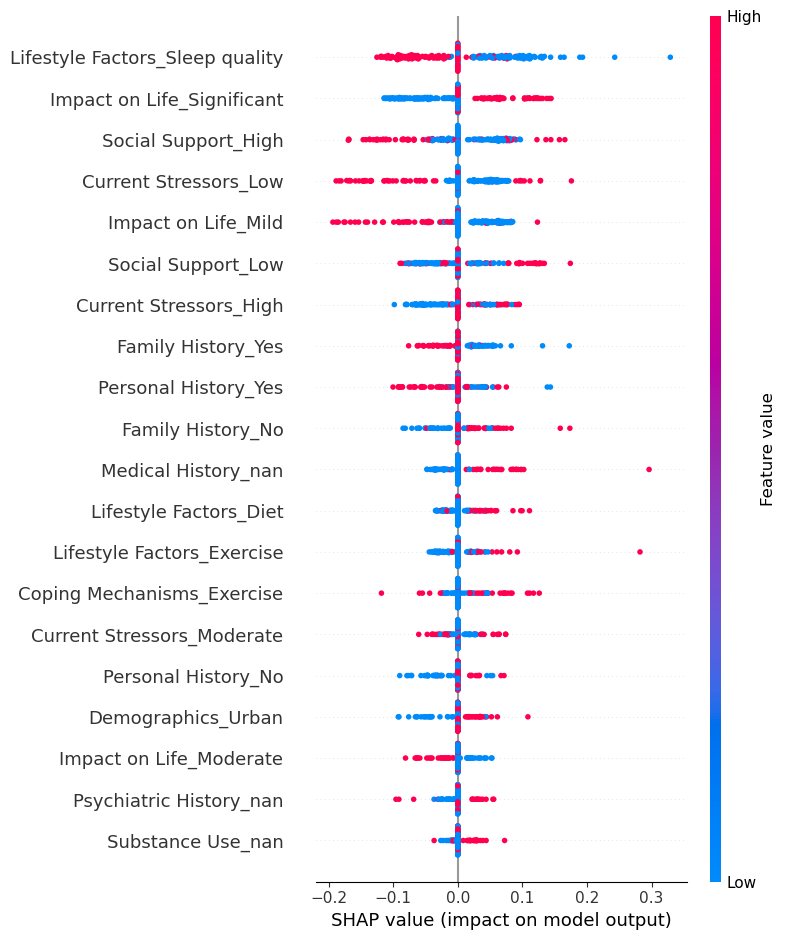

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\2560472947.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


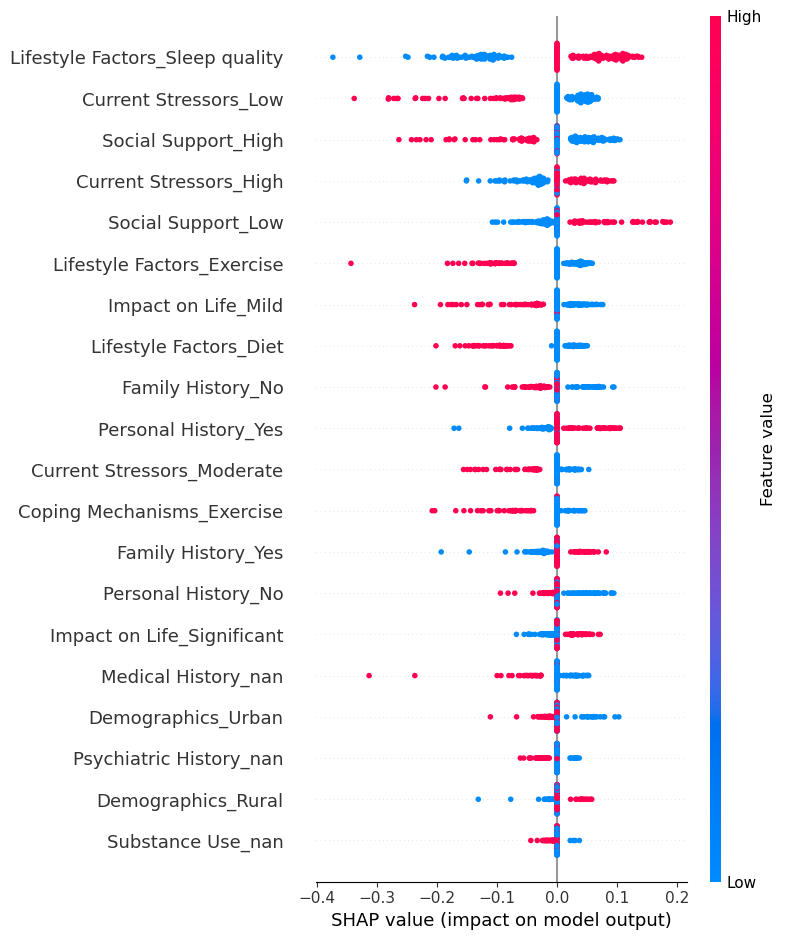


[XAI-Sev] Processing Generation: Boomers


  0%|          | 0/200 [00:00<?, ?it/s]

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\2560472947.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


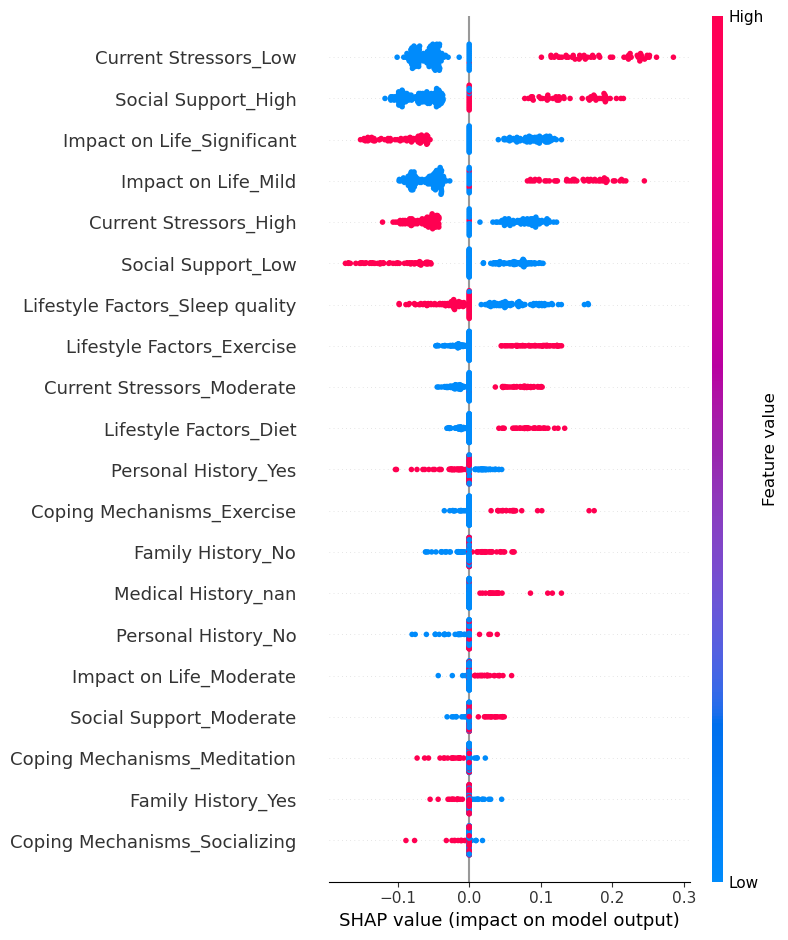

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\2560472947.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


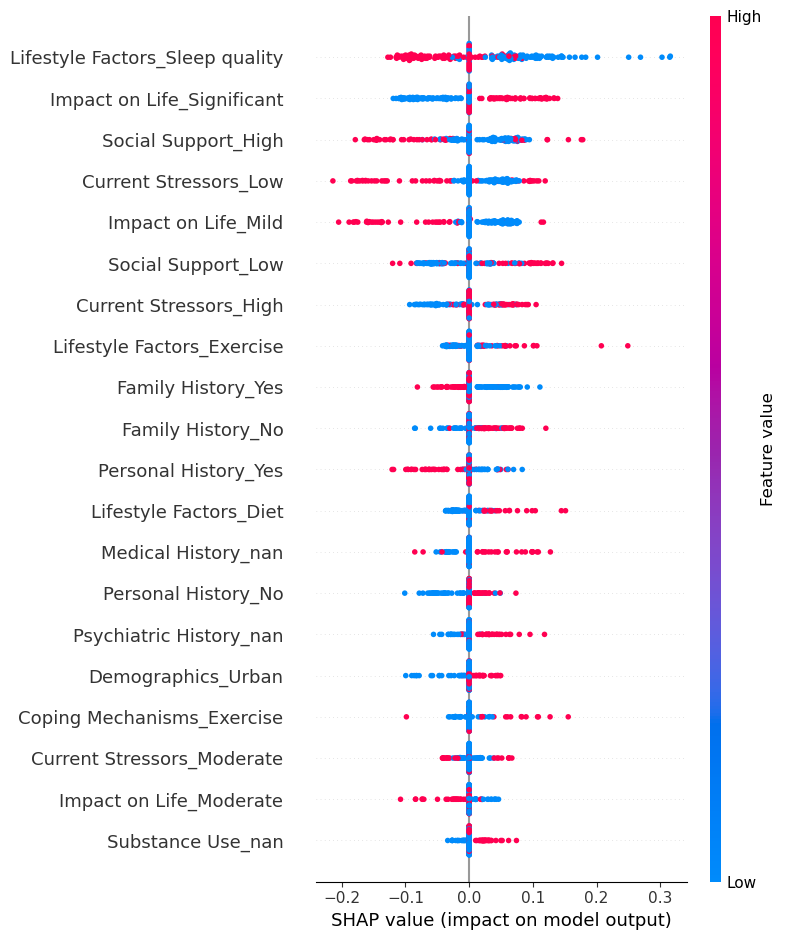

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12300\2560472947.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


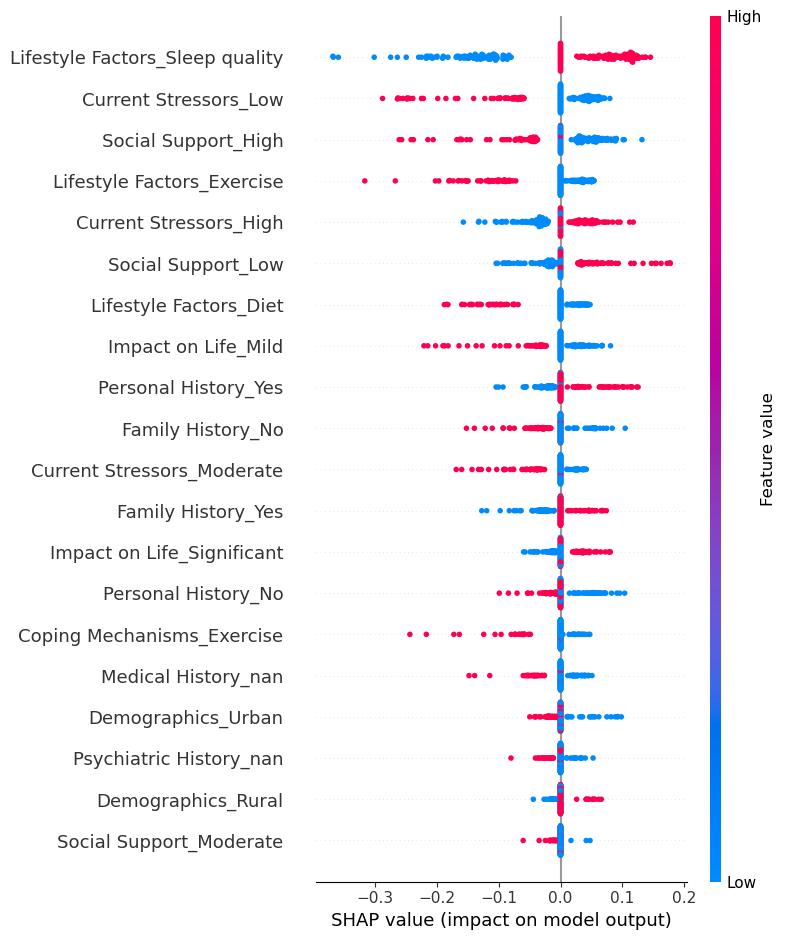

In [61]:
# ============================================================
# PART 7: SEVERITY XAI SPLICED BY GENERATION (Mild, Mod, Sev)
# ============================================================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("STARTING XAI SHAP ANALYSIS FOR SEVERITY (By Generation)")
print("="*60)

# 1. Generation Logic
def get_generation(age):
    if pd.isna(age): return "Unknown"
    if age <= 26: return "Gen Z"
    elif age <= 42: return "Millennials"
    elif age <= 58: return "Gen X"
    else: return "Boomers"

# 2. Prepare Data
try:
    feature_names_sev = preprocessor_ann.get_feature_names_out()
    feature_names_sev = [f.replace('num__', '').replace('cat__', '') for f in feature_names_sev]
except:
    feature_names_sev = [f"Feat {i}" for i in range(X_test_all_ann.shape[1])]

xai_sev_df = pd.DataFrame(X_test_all_ann, columns=feature_names_sev)
xai_sev_df['Generations'] = test_df['Age'].apply(get_generation).values

# 3. Initialize SHAP with the SEVERITY model
print("[XAI-Sev] Initializing SHAP Explainer...")

# Use background sample (Force to numpy to avoid pandas indexing issues)
background_sample_sev = shap.sample(X_train_smote_ann, 100)
if isinstance(background_sample_sev, pd.DataFrame):
    background_sample_sev = background_sample_sev.values

# --- FINAL ROBUST WRAPPER ---
# This wrapper enforces a (N, 3) output shape no matter what.
def predict_proba_sev_fn(x):
    # Ensure input is numpy
    if isinstance(x, pd.DataFrame):
        x = x.values
    
    # Use the RAW Keras model .predict()
    # This returns (N, 3) for a 3-class Softmax model
    preds = final_best_ann_sev.model_.predict(x, verbose=0)
    
    # Force output to be a numpy array
    preds = np.array(preds)
    
    # If the model somehow returns (N, 1, 3) or similar, squeeze it
    if preds.ndim == 3:
        preds = np.squeeze(preds)
        
    # Safety Check: If dimensionality collapsed to (3,) for a single sample,
    # reshape it back to (1, 3) so SHAP treats it as a matrix row.
    if preds.ndim == 1:
        preds = preds.reshape(1, -1)
        
    return preds

explainer_sev = shap.KernelExplainer(predict_proba_sev_fn, background_sample_sev)

# 4. Loop Generations and Output 3 Plots Per Gen
gen_order = ['Gen Z', 'Millennials', 'Gen X', 'Boomers']
class_labels = ["Mild", "Moderate", "Severe"] 

for gen in gen_order:
    print(f"\n[XAI-Sev] Processing Generation: {gen}")
    
    gen_data = xai_sev_df[xai_sev_df['Generations'] == gen].drop(columns=['Generations'])
    X_gen_matrix = gen_data.values
    
    if len(X_gen_matrix) == 0:
        print(f"  -> No data for {gen}")
        continue
    
    # Subsample to 50 for speed
    if len(X_gen_matrix) > 200: 
        X_gen_matrix = X_gen_matrix[:200]

    # Calculate SHAP values
    shap_values_sev = explainer_sev.shap_values(X_gen_matrix)
    
    # 5. Generate plots
    # With the wrapper strictly returning (N, 3), SHAP usually returns a LIST of 3 arrays:
    # [Array_Class0, Array_Class1, Array_Class2]
    
    vals_source = []
    if isinstance(shap_values_sev, list):
        vals_source = shap_values_sev
    elif isinstance(shap_values_sev, np.ndarray) and shap_values_sev.ndim == 3:
        # If it returns one 3D array (Samples, Features, Classes), split it
        vals_source = [shap_values_sev[:, :, i] for i in range(shap_values_sev.shape[2])]
    else:
        # Fallback
        vals_source = [shap_values_sev]

    # Plot
    for i, vals in enumerate(vals_source):
        label = class_labels[i] if i < len(class_labels) else f"Class {i}"
        
        plt.figure(figsize=(10, 5))
        plt.title(f"Factors driving '{label}' Severity: {gen}")
        
        shap.summary_plot(
            vals, 
            X_gen_matrix, 
            feature_names=feature_names_sev,
            show=False
        )
        plt.show()

### End of Code

In [ ]:
# import pandas as pd
# import numpy as np
# import joblib
# import os

# print("================================================")
# print("GENERATING DETAILED PROOF OF PREDICTION CSV (FIXED)")
# print("================================================")

# # 1. Load the Saved Models
# try:
#     path_occ = '../saved_models/ann_detection_model.pkl'
#     path_sev = '../saved_models/ann_severity_model.pkl'
    
#     model_occ_loaded = joblib.load(path_occ)
#     model_sev_loaded = joblib.load(path_sev)
#     print("✅ Loaded both ANN models from disk successfully.")
# except FileNotFoundError:
#     print("❌ Error: Saved model files not found. Using variables from memory...")
#     # Fallback logic if files missing
#     try:
#         model_occ_loaded = final_best_ann 
#         model_sev_loaded = final_best_ann 
#     except NameError:
#         print("❌ Critical: Neither saved files nor memory variables found.")

# # 2. Predict Occurrence on Test Set
# print("🔮 Predicting Occurrence...")
# # Ensure X_test_ann is defined (from your notebook execution)
# # SciKeras predict returns class labels (0 or 1)
# pred_occ_classes = model_occ_loaded.predict(X_test_ann) 
# pred_occ_classes = pred_occ_classes.flatten().astype(int)

# # 3. Predict Severity on Test Set
# print("🔮 Predicting Severity...")
# # The ANN Severity model (SciKeras wrapper) outputs 1, 2, 3 directly
# pred_sev_classes = model_sev_loaded.predict(X_test_all_ann)
# pred_sev_classes = pred_sev_classes.flatten().astype(int)

# # 4. Create the Proof DataFrame
# # Use reset_index to ensure alignment between the dataframe and new prediction arrays
# proof_df = test_df.copy().reset_index(drop=True)

# # --- Map Model Output 0/1 -> No/Yes ---
# proof_df['Predicted_Occurrence_Str'] = pd.Series(pred_occ_classes).map({0: 'No', 1: 'Yes'})

# # --- Map Severity Output 1/2/3 -> Mild/Mod/Sev ---
# # FIX: Adjusted map to match model output (1, 2, 3)
# sev_map_str = {1: 'Mild', 2: 'Moderate', 3: 'Severe'}
# proof_df['Predicted_Severity_Raw'] = pd.Series(pred_sev_classes)
# proof_df['Predicted_Severity_Str'] = proof_df['Predicted_Severity_Raw'].map(sev_map_str)

# # --- Logic Correction: Handling Disagreements ---
# # If Occurrence is No, Severity should be N/A
# mask_no_panic = proof_df['Predicted_Occurrence_Str'] == 'No'
# proof_df.loc[mask_no_panic, 'Predicted_Severity_Str'] = 'N/A'

# # Case 2: Ground Truth Logic (Actual Values)
# # Map 1->Mild, 2->Mod, 3->Sev for easy reading
# gt_sev_map = {1: 'Mild', 2: 'Moderate', 3: 'Severe'}
# proof_df['Actual_Severity_Str'] = proof_df['Panic Attack Severity'].map(gt_sev_map).fillna('None')

# # 5. DEFINE COLUMNS (Added 'Severity' and 'Demographics')
# cols_to_show = [
#     'Age', 'Gender', 'Family History', 'Personal History', 'Current Stressors', 
#     'Symptoms', 
#     'Severity',       # <--- Input Feature (Added)
#     'Impact on Life', 
#     'Demography',     # <--- Input Feature (Try name 1)
#     'Demographics',   # <--- Input Feature (Try name 2 - main.py renaming implies this exists)
#     'Medical History', 
#     'Psychiatric History', 'Substance Use', 'Coping Mechanisms', 
#     'Social Support', 'Lifestyle Factors',
#     'Panic Disorder Diagnosis', 'Actual_Severity_Str',
#     'Predicted_Occurrence_Str', 'Predicted_Severity_Str'
# ]

# # Filter to ensure we only ask for columns that actually exist
# final_cols = [c for c in cols_to_show if c in proof_df.columns]
# final_proof_df = proof_df[final_cols]

# # 6. Save to CSV (Excel Safe Mode)
# filename = "ANN_Detailed_Test_Results.csv"
# # encoding='utf-8-sig' fixes the "SYLK/Emphasized Items" error in Excel
# final_proof_df.to_csv(filename, index=False, encoding='utf-8-sig')

# print(f"\n✅ SUCCESS! Proof file generated: {filename}")
# print("-" * 60)
# print(f"Total Rows: {len(final_proof_df)}")
# print("Preview of the first 5 rows:")
# print(final_proof_df.head())
# print("-" * 60)